In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import faiss
import sys
from pathlib import Path
from scipy.spatial.distance import cdist

# =====================
# === Import helpers ===
# =====================
module_path = '/home/cpanourg/projects/2-hdvc/'
if module_path not in sys.path:
    sys.path.append(module_path)

from src.utils import (
    load_dataset, compute_distance_tables_vectorized, compute_distance_tables_threaded,
    adc_distances_batch_numba
)

# ============================================================================
# CONFIGURATION: Modify these settings to control what gets plotted
# ============================================================================

# Choose which nbits values to plot (e.g., [8], [10], [8, 10], [8, 10, 12], etc.)
nbits = [4, 8, 10]

# Choose which datasets to plot (e.g., ['gist'], ['gist', 'deep'], ['gist', 'deep', 'glove'], etc.)
datasets_to_plot = ['gist', 'deep']

# Top-k value for rank preservation (recall@k)
k = 100

# Dataset configuration: Add new datasets here by adding entries to this dictionary
# Each entry should have: 'csv_path', 'dataset_path', 'query_path', 'train_size', 'divisor', and 'letter'
dataset_config = {
    'gist': {
        'csv_path': '/mnthdd/cpanourg/2-hdvc/results/relerr/gist_PQ_adc_vs_exact_eval.csv',
        'dataset_path': '/mnthdd/cpanourg/2-hdvc/data/gist/gist_base.fvecs',
        'query_path': '/mnthdd/cpanourg/2-hdvc/data/gist/gist_query.fvecs',
        'train_size': 500000,
        'divisor': 1000,
        'letter': 'K',
        'dim': 960
    },
    'deep': {
        'csv_path': '/mnthdd/cpanourg/2-hdvc/results/relerr/deep_PQ_adc_vs_exact_eval.csv',
        'dataset_path': '/mnthdd/cpanourg/2-hdvc/data/deep1b/dataset/test_1m.bin',
        'query_path': '/mnthdd/cpanourg/2-hdvc/data/deep1b/dataset/query_10k.bin',
        'train_size': 100000000,
        'divisor': 1000000,
        'letter': 'M',
        'dim': 96
    },
    'glove': {
        'csv_path': '/mnthdd/cpanourg/2-hdvc/results/relerr/glove_200d_PQ_adc_vs_exact_eval.csv',
        'dataset_path': '/mnthdd/cpanourg/2-hdvc/data/glove/splits/test.bin',
        'query_path': '/mnthdd/cpanourg/2-hdvc/data/glove/splits/queries.bin',
        'train_size': 1000000,
        'divisor': 1000000,
        'letter': 'M',
        'dim': 200
    }
    # Add new datasets here, for example:
    # 'new_dataset': {
    #     'csv_path': '/path/to/new_dataset_PQ_adc_vs_exact_eval.csv',
    #     'dataset_path': '/path/to/test_data.bin',
    #     'query_path': '/path/to/queries.bin',
    #     'train_size': 2000000,
    #     'divisor': 1000000,
    #     'letter': 'M',
    #     'dim': 128
    # }
}

# ============================================================================
# Load and process data
# ============================================================================

# Validate that all requested datasets exist in config
missing_datasets = [d for d in datasets_to_plot if d not in dataset_config]
if missing_datasets:
    raise ValueError(f"Datasets not found in config: {missing_datasets}. Available datasets: {list(dataset_config.keys())}")

# Load CSV data for all requested datasets
dataframes = {}
for dataset_name in datasets_to_plot:
    config = dataset_config[dataset_name]
    df = pd.read_csv(config['csv_path'])
    df['dataset'] = dataset_name
    dataframes[dataset_name] = df
    print(f"{dataset_name.capitalize()} dataset shape: {df.shape}")
    print(f"  nbits values available: {sorted(df['nbits'].unique())}")

# Store filtered dataframes in a dictionary: {dataset_name: {nbits_value: dataframe}}
filtered_data = {dataset_name: {} for dataset_name in datasets_to_plot}

# Filter data for each nbits value and each dataset
for dataset_name in datasets_to_plot:
    config = dataset_config[dataset_name]
    df = dataframes[dataset_name]
    
    for nbits_val in nbits:
        filtered_data[dataset_name][nbits_val] = df[
            (df['nbits'] == nbits_val) & (df['train_size'] == config['train_size'])
        ].copy()

# Print filtering results
print("\n" + "="*70)
print("Filtering Results")
print("="*70)
for dataset_name in datasets_to_plot:
    config = dataset_config[dataset_name]
    train_size_str = f"{config['train_size']//config['divisor']}{config['letter']}"
    for nbits_val in nbits:
        df_filtered = filtered_data[dataset_name][nbits_val]
        print(f"\n{dataset_name.capitalize()} filtered (nbits={nbits_val}, train_size={train_size_str}): {len(df_filtered)} rows")
        if len(df_filtered) > 0:
            print(f"  n_subquantizers values available: {sorted(df_filtered['n_subquantizers'].unique())}")



Gist dataset shape: (99, 23)
  nbits values available: [4, 5, 6, 8, 9, 10, 12, 14, 16]
Deep dataset shape: (81, 23)
  nbits values available: [4, 6, 8, 10, 12, 14, 16]

Filtering Results

Gist filtered (nbits=4, train_size=500K): 33 rows
  n_subquantizers values available: [1, 2, 3, 4, 5, 6, 8, 10, 12, 15, 16, 20, 24, 30, 32, 40, 48, 60, 64, 80, 96, 120, 160, 192, 240, 320, 480, 960]

Gist filtered (nbits=8, train_size=500K): 18 rows
  n_subquantizers values available: [1, 4, 8, 16, 32, 64, 80, 96, 120, 160, 192, 240, 320, 480, 960]

Gist filtered (nbits=10, train_size=500K): 33 rows
  n_subquantizers values available: [1, 2, 3, 4, 5, 6, 8, 10, 12, 15, 16, 20, 24, 30, 32, 40, 48, 60, 64, 80, 96, 120, 160, 192, 240, 320, 480, 960]

Deep filtered (nbits=4, train_size=100M): 18 rows
  n_subquantizers values available: [1, 2, 3, 4, 6, 8, 12, 16, 24, 32, 48, 96]

Deep filtered (nbits=8, train_size=100M): 16 rows
  n_subquantizers values available: [1, 2, 3, 4, 6, 8, 12, 16, 24, 32, 48, 96]


Loading data...
DB: (10000, 96), Queries: (1000, 96), Train: (1000000, 96)
Training PQ: M=32, nbits=8
Relative error (mean ± std): 0.031379 ± 0.023460


In [2]:
# ============================================================================
# Compute Rank Preservation (Recall@k) for each experiment
# ============================================================================

def compute_recall_at_k(I_exact, I_adc, k):
    """
    Compute recall@k: average fraction of true top-k that are found in ADC top-k.
    
    Args:
        I_exact: (nq, k) array of exact top-k indices
        I_adc: (nq, k) array of ADC top-k indices
        k: top-k value
    
    Returns:
        recall@k value (0.0 to 1.0)
    """
    nq = I_exact.shape[0]
    total_recall = 0.0
    
    for i in range(nq):
        # Get true top-k and ADC top-k as sets
        true_topk = set(I_exact[i, :k])
        adc_topk = set(I_adc[i, :k])
        
        # Count how many true top-k are in ADC top-k
        intersection = len(true_topk & adc_topk)
        recall_i = intersection / k
        total_recall += recall_i
    
    return total_recall / nq


def compute_rank_preservation_for_experiment(experiment_folder, dataset_name, test_db, queries, I_exact, k=100):
    """
    Compute rank preservation metrics for a single experiment.
    
    Args:
        experiment_folder: Path to experiment folder
        dataset_name: Name of the dataset
        test_db: Pre-loaded database vectors (already sampled)
        queries: Pre-loaded query vectors (already sampled)
        I_exact: Pre-computed exact top-k indices (nq, k)
        k: Top-k value for recall
    
    Returns:
        dict with recall@k and other metrics, or None if computation fails
    """
    model_path = Path(experiment_folder) / 'pq_model.index'
    
    if not model_path.exists():
        return None
    
    try:
        # Load model
        pq_index = faiss.read_index(str(model_path))
        pq = pq_index.pq
        dim = pq.d
        n_subquantizers = pq.M
        nbits = pq.nbits
        
        # Encode database
        codes = pq.compute_codes(test_db)
        
        # Compute distance tables
        ksub = 1 << nbits
        centroids = faiss.vector_to_array(pq.centroids).reshape(n_subquantizers, ksub, dim // n_subquantizers)
        
        n_sample_q = len(queries)
        if n_sample_q > 1000:
            dis_tables = compute_distance_tables_threaded(queries, centroids, n_subquantizers, ksub, dim)
        else:
            dis_tables = compute_distance_tables_vectorized(queries, centroids, n_subquantizers, ksub, dim)
        
        # Compute ADC distances only (exact distances already computed)
        adc_distances = adc_distances_batch_numba(dis_tables, codes, n_subquantizers)
        
        # Clip ADC distances to safe range
        max_safe_value = np.finfo(np.float32).max / 10.0
        adc_distances = np.clip(adc_distances, 0, max_safe_value)
        
        # Get top-k indices for ADC (exact top-k already provided)
        I_adc = np.argsort(adc_distances, axis=1)[:, :k]
        
        # Compute recall@k using pre-computed exact top-k
        recall_k = compute_recall_at_k(I_exact, I_adc, k)
        
        return {
            'recall_at_k': recall_k,
            'n_subquantizers': n_subquantizers,
            'nbits': nbits,
            'dim': dim
        }
        
    except Exception as e:
        print(f"  ❌ Error computing rank preservation: {e}")
        return None


# Check if recall columns already exist in CSV
recall_col = f'recall_at_{k}'
has_recall_data = False

for dataset_name in datasets_to_plot:
    if recall_col in dataframes[dataset_name].columns:
        has_recall_data = True
        break

# Compute rank preservation if not already in CSV
if not has_recall_data:
    print("\n" + "="*70)
    print(f"Computing Rank Preservation (Recall@{k})")
    print("="*70)
    
    # Load datasets once for all experiments
    print("\n" + "="*70)
    print("Loading datasets (one-time load)...")
    print("="*70)
    loaded_datasets = {}
    sample_db = 10000
    sample_queries = 1000
    
    for dataset_name in datasets_to_plot:
        config = dataset_config[dataset_name]
        print(f"\nLoading {dataset_name.upper()} dataset...")
        
        # Load test database
        test_db_full, _ = load_dataset(
            config['dataset_path'],
            None,
            config['dim'],
            db_chunk_size=sample_db,
            qr_chunk_size=None
        )
        
        # Load queries
        queries_full, _ = load_dataset(
            config['query_path'],
            None,
            config['dim'],
            db_chunk_size=None,
            qr_chunk_size=sample_queries
        )
        
        # Limit sizes
        n_sample_db = min(sample_db, len(test_db_full))
        n_sample_q = min(sample_queries, len(queries_full))
        test_db = test_db_full[:n_sample_db]
        queries = queries_full[:n_sample_q]
        
        # Compute exact distances once (same for all experiments on this dataset)
        print(f"  Computing exact distances (one-time computation)...")
        max_safe_value = np.finfo(np.float32).max / 10.0
        with np.errstate(over='ignore'):
            exact_distances_64 = cdist(queries, test_db, metric="sqeuclidean")
        exact_distances = np.clip(exact_distances_64, 0, max_safe_value).astype(np.float32)
        
        # Get exact top-k indices once (same for all experiments)
        I_exact = np.argsort(exact_distances, axis=1)[:, :k]
        
        loaded_datasets[dataset_name] = {
            'test_db': test_db,
            'queries': queries,
            'I_exact': I_exact  # Pre-computed exact top-k indices
        }
        print(f"  ✅ Loaded {n_sample_db} database vectors and {n_sample_q} queries")
        print(f"  ✅ Computed exact distances and top-{k} indices (will be reused for all experiments)")
    
    # Add recall column to dataframes
    for dataset_name in datasets_to_plot:
        if recall_col not in dataframes[dataset_name].columns:
            dataframes[dataset_name][recall_col] = np.nan
    
    # Compute for each experiment
    total_experiments = sum(len(filtered_data[d][n]) for d in datasets_to_plot for n in nbits)
    current_exp = 0
    
    for dataset_name in datasets_to_plot:
        config = dataset_config[dataset_name]
        df = dataframes[dataset_name]
        
        # Get pre-loaded data for this dataset (including pre-computed exact top-k)
        test_db = loaded_datasets[dataset_name]['test_db']
        queries = loaded_datasets[dataset_name]['queries']
        I_exact = loaded_datasets[dataset_name]['I_exact']
        
        for idx, row in df.iterrows():
            # Only compute for filtered experiments
            if (row['nbits'] in nbits and 
                row['train_size'] == config['train_size'] and
                pd.isna(row.get(recall_col, np.nan))):
                
                current_exp += 1
                experiment_folder = row['experiment_folder']
                print(f"\n[{current_exp}/{total_experiments}] Computing: {dataset_name} - {Path(experiment_folder).name}")
                
                result = compute_rank_preservation_for_experiment(
                    experiment_folder, dataset_name, test_db, queries, I_exact, k=k
                )
                
                if result:
                    df.at[idx, recall_col] = result['recall_at_k']
                    print(f"  ✅ Recall@{k} = {result['recall_at_k']:.4f}")
    
    # Update filtered_data with new recall values
    for dataset_name in datasets_to_plot:
        config = dataset_config[dataset_name]
        df = dataframes[dataset_name]
        
        for nbits_val in nbits:
            filtered_data[dataset_name][nbits_val] = df[
                (df['nbits'] == nbits_val) & 
                (df['train_size'] == config['train_size']) &
                (df[recall_col].notna())
            ].copy()
    
    # Save updated dataframes back to CSV files
    print("\n" + "="*70)
    print("Saving recall values to CSV files...")
    print("="*70)
    for dataset_name in datasets_to_plot:
        config = dataset_config[dataset_name]
        csv_path = config['csv_path']
        df = dataframes[dataset_name]
        
        # Save to CSV
        df.to_csv(csv_path, index=False)
        print(f"✅ Saved {len(df)} rows to {csv_path}")
        if recall_col in df.columns:
            num_computed = df[recall_col].notna().sum()
            print(f"   - {num_computed} rows have {recall_col} values")
    
    print("\n✅ Rank preservation computation complete!")

else:
    print(f"\n✅ Rank preservation data already exists in CSV (column: {recall_col})")
    # Update filtered_data to only include rows with recall data
    for dataset_name in datasets_to_plot:
        config = dataset_config[dataset_name]
        df = dataframes[dataset_name]
        
        for nbits_val in nbits:
            filtered_data[dataset_name][nbits_val] = df[
                (df['nbits'] == nbits_val) & 
                (df['train_size'] == config['train_size']) &
                (df[recall_col].notna())
            ].copy()

# Print summary
print("\n" + "="*70)
print(f"Rank Preservation Summary (Recall@{k})")
print("="*70)
for dataset_name in datasets_to_plot:
    config = dataset_config[dataset_name]
    train_size_str = f"{config['train_size']//config['divisor']}{config['letter']}"
    for nbits_val in nbits:
        df_filtered = filtered_data[dataset_name][nbits_val]
        if len(df_filtered) > 0:
            recall_values = df_filtered[recall_col].values
            print(f"\n{dataset_name.capitalize()} (nbits={nbits_val}, train_size={train_size_str}):")
            print(f"  Recall@{k} range: {recall_values.min():.4f} - {recall_values.max():.4f}")
            print(f"  Recall@{k} mean: {recall_values.mean():.4f}")




✅ Rank preservation data already exists in CSV (column: recall_at_100)

Rank Preservation Summary (Recall@100)

Gist (nbits=4, train_size=500K):
  Recall@100 range: 0.0123 - 0.0625
  Recall@100 mean: 0.0247

Gist (nbits=8, train_size=500K):
  Recall@100 range: 0.1846 - 0.9913
  Recall@100 mean: 0.7058

Gist (nbits=10, train_size=500K):
  Recall@100 range: 0.0112 - 0.0738
  Recall@100 mean: 0.0196

Deep (nbits=4, train_size=100M):
  Recall@100 range: 0.0121 - 0.1043
  Recall@100 mean: 0.0280

Deep (nbits=8, train_size=100M):
  Recall@100 range: 0.3620 - 0.9855
  Recall@100 mean: 0.7011

Deep (nbits=10, train_size=100M):
  Recall@100 range: 0.0106 - 0.1001
  Recall@100 mean: 0.0306


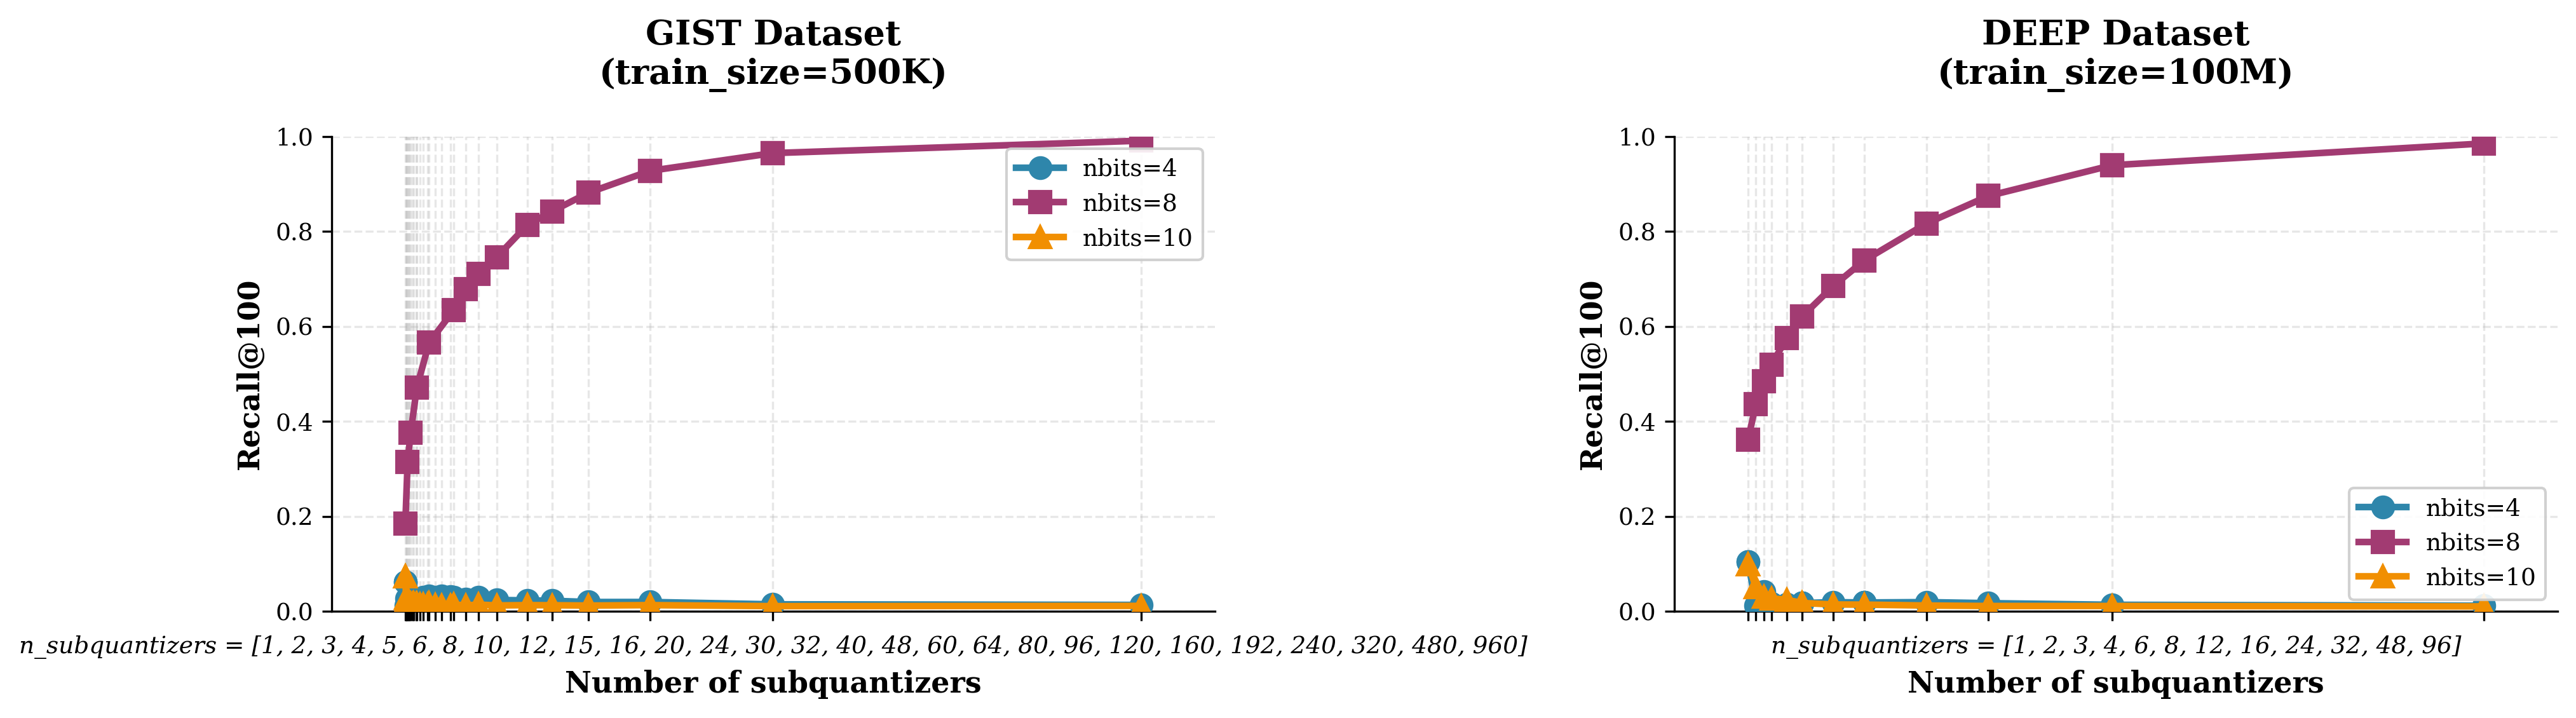


Summary: Rank Preservation (Recall@100) vs n_subquantizers (nbits=4, 8, 10)

GIST Dataset (nbits=4):
  n_subquantizers=  1: Recall@100=0.0625
  n_subquantizers=  1: Recall@100=0.0625
  n_subquantizers=  2: Recall@100=0.0123
  n_subquantizers=  3: Recall@100=0.0267
  n_subquantizers=  4: Recall@100=0.0147
  n_subquantizers=  4: Recall@100=0.0147
  n_subquantizers=  5: Recall@100=0.0195
  n_subquantizers=  6: Recall@100=0.0137
  n_subquantizers=  8: Recall@100=0.0165
  n_subquantizers=  8: Recall@100=0.0164
  n_subquantizers= 10: Recall@100=0.0170
  n_subquantizers= 12: Recall@100=0.0193
  n_subquantizers= 15: Recall@100=0.0223
  n_subquantizers= 16: Recall@100=0.0201
  n_subquantizers= 16: Recall@100=0.0201
  n_subquantizers= 20: Recall@100=0.0230
  n_subquantizers= 24: Recall@100=0.0298
  n_subquantizers= 30: Recall@100=0.0305
  n_subquantizers= 32: Recall@100=0.0331
  n_subquantizers= 40: Recall@100=0.0299
  n_subquantizers= 48: Recall@100=0.0323
  n_subquantizers= 60: Recall@100=0.0

In [3]:
# ============================================================================
# Plot 1: Rank Preservation (Recall@k) vs n_subquantizers (for different nbits)
# ============================================================================

# Set style (paper-quality minimalist)
plt.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "font.size": 10,
    "font.family": "serif",
    "axes.labelsize": 10,
    "axes.titlesize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# Define colors and markers for different nbits values
color_palette = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A994E', '#BC4749', '#7209B7', '#06FFA5']
markers = ['o', 's', '^', 'D', 'v', 'p', '*', 'X']

# Create a mapping of nbits values to colors and markers
nbits_colors = {nbits_val: color_palette[i % len(color_palette)] 
                for i, nbits_val in enumerate(sorted(nbits))}
nbits_markers = {nbits_val: markers[i % len(markers)] 
                 for i, nbits_val in enumerate(sorted(nbits))}

# Create plots for each selected dataset
num_datasets = len(datasets_to_plot)

# Increase figure size for better visibility
fig, axes = plt.subplots(1, num_datasets, figsize=(7 * num_datasets, 5))

# If only one dataset, axes might be a single object
if num_datasets == 1:
    axes = [axes]

for idx, dataset_name in enumerate(datasets_to_plot):
    ax = axes[idx]
    config = dataset_config[dataset_name]
    train_size_str = f"{config['train_size']//config['divisor']}{config['letter']}"
    
    # Check if we have any data for this dataset
    has_any_data = any(len(filtered_data[dataset_name][nbits_val]) > 0 for nbits_val in nbits)
    
    if not has_any_data:
        ax.text(0.5, 0.5, f'No rank preservation data for {dataset_name}\n(train_size={train_size_str})', 
                ha='center', va='center', transform=ax.transAxes, fontsize=12)
        ax.set_title(f'{dataset_name.upper()} Dataset\n(train_size={train_size_str})', fontweight='bold')
        continue
    
    # Plot each nbits value
    for nbits_val in sorted(nbits):
        df_filtered = filtered_data[dataset_name][nbits_val]
        
        if len(df_filtered) > 0:
            df_sorted = df_filtered.sort_values('n_subquantizers')
            ax.plot(
                df_sorted['n_subquantizers'], 
                df_sorted[recall_col],
                marker=nbits_markers[nbits_val],
                markersize=8,
                linewidth=2.5,
                color=nbits_colors[nbits_val],
                label=f'nbits={nbits_val}',
                zorder=3
            )
    
    # Styling
    ax.set_xlabel('Number of subquantizers', fontsize=11, fontweight='bold', labelpad=15)
    ax.set_ylabel(f'Recall@{k}', fontsize=11, fontweight='bold')
    ax.set_title(f'{dataset_name.upper()} Dataset\n(train_size={train_size_str})', 
                 fontsize=13, fontweight='bold', pad=20)
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.8, which='both')
    ax.legend(fontsize=9, loc='best', framealpha=0.9)
    
    # Get all unique n_subquantizers values from all nbits datasets
    all_nsub = set()
    for nbits_val in nbits:
        df_filtered = filtered_data[dataset_name][nbits_val]
        if len(df_filtered) > 0:
            all_nsub.update(df_filtered['n_subquantizers'].unique())
    unique_nsub = sorted(all_nsub)
    
    # Set x-axis ticks but remove labels - show values as list instead
    ax.set_xticks(unique_nsub)
    ax.set_xticklabels([])  # Remove all tick labels
    
    # Add text box below showing all x-axis values as a list (above the xlabel)
    nsub_list_str = ', '.join([str(int(x)) for x in unique_nsub])
    ax.text(0.5, -0.05, f'n_subquantizers = [{nsub_list_str}]', 
            transform=ax.transAxes, ha='center', va='top', 
            fontsize=9, style='italic')
    
    # Set reasonable y-axis limits with some padding (considering all datasets)
    y_min = float('inf')
    y_max = float('-inf')
    for nbits_val in nbits:
        df_filtered = filtered_data[dataset_name][nbits_val]
        if len(df_filtered) > 0:
            y_min = min(y_min, df_filtered[recall_col].min())
            y_max = max(y_max, df_filtered[recall_col].max())
    
    y_range = y_max - y_min
    if y_range > 0:
        ax.set_ylim(max(0, y_min - y_range * 0.05), min(1.0, y_max + y_range * 0.1))
    else:
        ax.set_ylim(0, 1.0)
    # Better margins (extra bottom margin for the text)
    ax.margins(x=0.1, y=0.05)

plt.tight_layout(pad=3.0, rect=[0, 0.10, 1, 0.98])
plt.show()

# Print summary statistics
nbits_str = ', '.join([str(n) for n in sorted(nbits)])
print("\n" + "="*70)
print(f"Summary: Rank Preservation (Recall@{k}) vs n_subquantizers (nbits={nbits_str})")
print("="*70)
for dataset_name in datasets_to_plot:
    has_any_data = any(len(filtered_data[dataset_name][nbits_val]) > 0 for nbits_val in nbits)
    if not has_any_data:
        continue
    
    for nbits_val in sorted(nbits):
        df_filtered = filtered_data[dataset_name][nbits_val]
        if len(df_filtered) > 0:
            df_sorted = df_filtered.sort_values('n_subquantizers')
            print(f"\n{dataset_name.upper()} Dataset (nbits={nbits_val}):")
            for _, row in df_sorted.iterrows():
                print(f"  n_subquantizers={row['n_subquantizers']:3d}: Recall@{k}={row[recall_col]:.4f}")



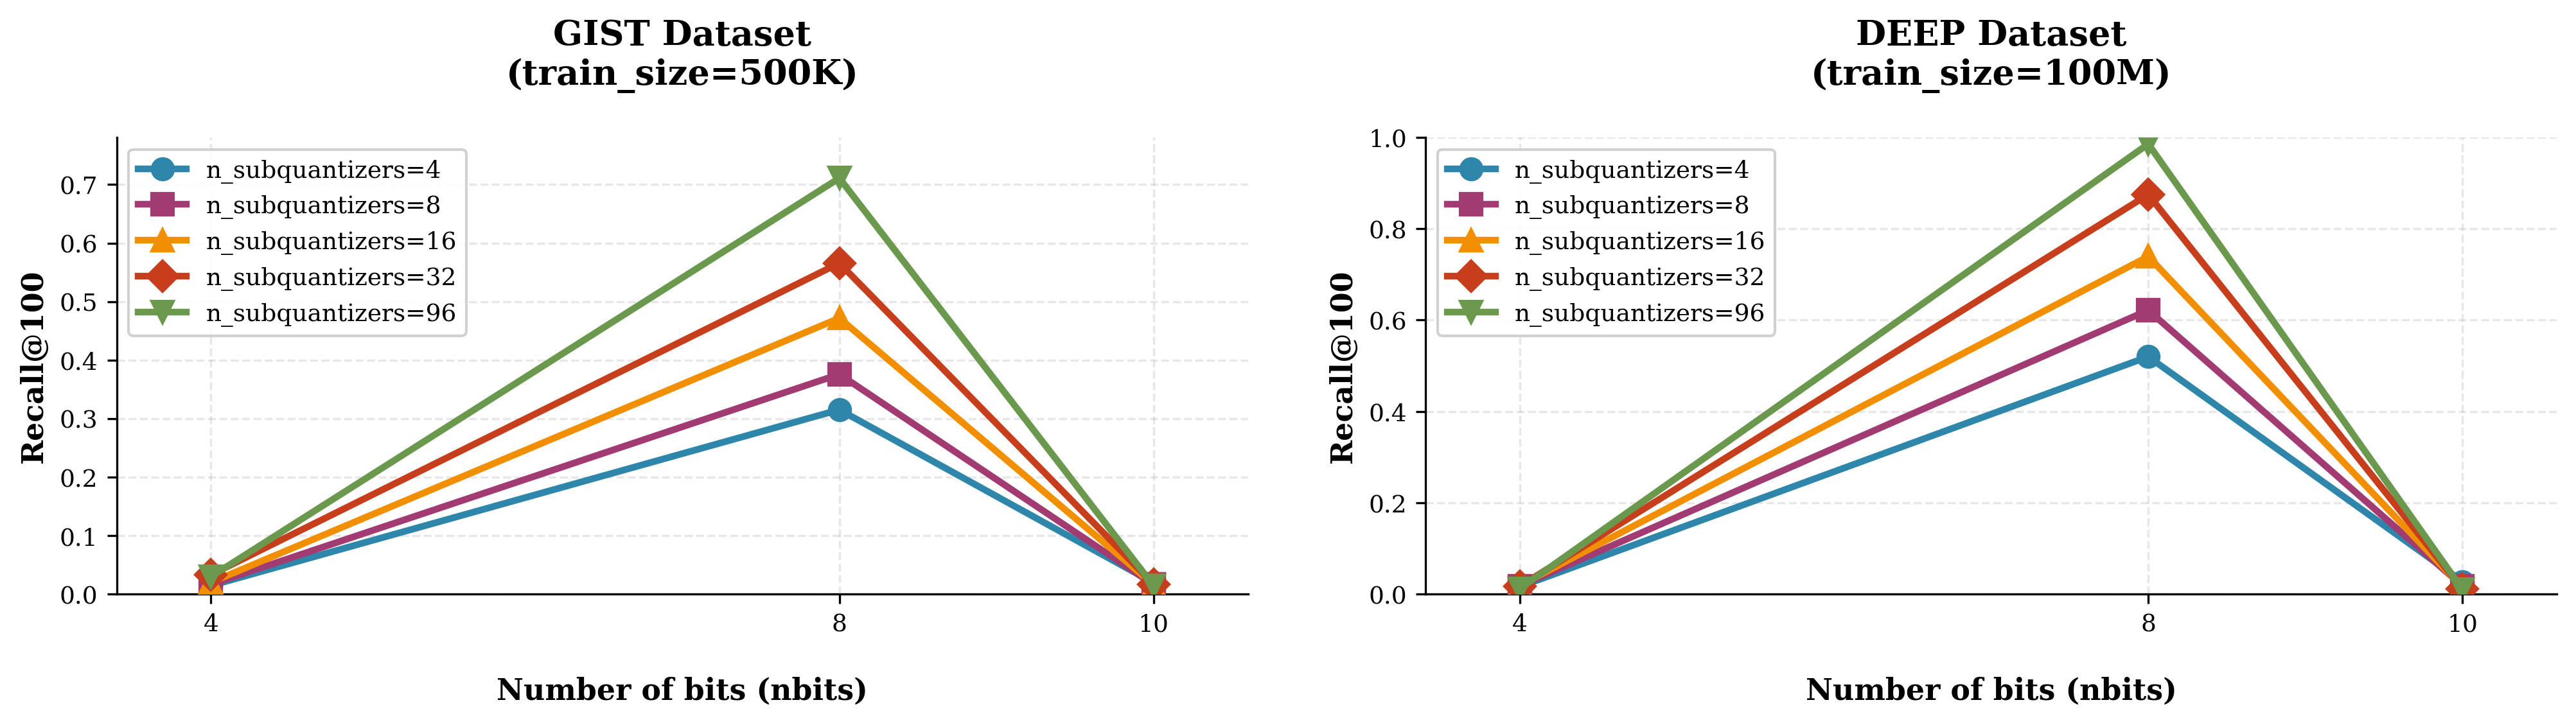


Summary: Rank Preservation (Recall@100) vs nbits (n_subquantizers=4, 8, 16, 32, 96)

GIST Dataset (n_subquantizers=4):
  nbits=  4: Recall@100=0.0147
  nbits=  4: Recall@100=0.0147
  nbits=  8: Recall@100=0.3153
  nbits= 10: Recall@100=0.0195
  nbits= 10: Recall@100=0.0195

GIST Dataset (n_subquantizers=8):
  nbits=  4: Recall@100=0.0164
  nbits=  4: Recall@100=0.0165
  nbits=  8: Recall@100=0.3759
  nbits= 10: Recall@100=0.0163
  nbits= 10: Recall@100=0.0163
  nbits= 10: Recall@100=0.0163

GIST Dataset (n_subquantizers=16):
  nbits=  4: Recall@100=0.0201
  nbits=  4: Recall@100=0.0201
  nbits=  8: Recall@100=0.4718
  nbits= 10: Recall@100=0.0162
  nbits= 10: Recall@100=0.0162

GIST Dataset (n_subquantizers=32):
  nbits=  4: Recall@100=0.0331
  nbits=  8: Recall@100=0.5659
  nbits= 10: Recall@100=0.0173

GIST Dataset (n_subquantizers=96):
  nbits=  4: Recall@100=0.0300
  nbits=  8: Recall@100=0.7110
  nbits= 10: Recall@100=0.0145

DEEP Dataset (n_subquantizers=4):
  nbits=  4: Recall@

In [4]:
# ============================================================================
# Plot 2: Rank Preservation (Recall@k) vs nbits (for different n_subquantizers)
# ============================================================================

# Choose which n_subquantizers values to plot
n_subquantizers_list = [ 4, 8, 16, 32, 96] # Change this list to plot different n_subquantizers values

# Filter data for each n_subquantizers value and each dataset
filtered_data_nsubq = {dataset_name: {} for dataset_name in datasets_to_plot}

for dataset_name in datasets_to_plot:
    config = dataset_config[dataset_name]
    df = dataframes[dataset_name]
    
    for n_subq in n_subquantizers_list:
        filtered_data_nsubq[dataset_name][n_subq] = df[
            (df['n_subquantizers'] == n_subq) & 
            (df['train_size'] == config['train_size']) &
            (df[recall_col].notna())  # Only include rows with recall data
        ].copy()

# Create a mapping of n_subquantizers values to colors and markers
nsubq_colors = {n_subq: color_palette[i % len(color_palette)] 
                for i, n_subq in enumerate(sorted(n_subquantizers_list))}
nsubq_markers = {n_subq: markers[i % len(markers)] 
                 for i, n_subq in enumerate(sorted(n_subquantizers_list))}

# Create plots for each selected dataset
fig, axes = plt.subplots(1, num_datasets, figsize=(7 * num_datasets, 5))

# If only one dataset, axes might be a single object
if num_datasets == 1:
    axes = [axes]

for idx, dataset_name in enumerate(datasets_to_plot):
    ax = axes[idx]
    config = dataset_config[dataset_name]
    train_size_str = f"{config['train_size']//config['divisor']}{config['letter']}"
    
    # Check if we have any data for this dataset
    has_any_data = any(len(filtered_data_nsubq[dataset_name][n_subq]) > 0 for n_subq in n_subquantizers_list)
    
    if not has_any_data:
        ax.text(0.5, 0.5, f'No rank preservation data for {dataset_name}\n(train_size={train_size_str})', 
                ha='center', va='center', transform=ax.transAxes, fontsize=12)
        ax.set_title(f'{dataset_name.upper()} Dataset\n(train_size={train_size_str})', fontweight='bold')
        continue
    
    # Plot each n_subquantizers value
    for n_subq in sorted(n_subquantizers_list):
        df_filtered = filtered_data_nsubq[dataset_name][n_subq]
        
        if len(df_filtered) > 0:
            df_sorted = df_filtered.sort_values('nbits')
            ax.plot(
                df_sorted['nbits'], 
                df_sorted[recall_col],
                marker=nsubq_markers[n_subq],
                markersize=8,
                linewidth=2.5,
                color=nsubq_colors[n_subq],
                label=f'n_subquantizers={n_subq}',
                zorder=3
            )
    
    # Styling
    ax.set_xlabel('Number of bits (nbits)', fontsize=11, fontweight='bold', labelpad=15)
    ax.set_ylabel(f'Recall@{k}', fontsize=11, fontweight='bold')
    ax.set_title(f'{dataset_name.upper()} Dataset\n(train_size={train_size_str})', 
                 fontsize=13, fontweight='bold', pad=20)
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.8, which='both')
    ax.legend(fontsize=9, loc='best', framealpha=0.9)
    
    # Get all unique nbits values from all n_subquantizers datasets
    all_nbits = set()
    for n_subq in n_subquantizers_list:
        df_filtered = filtered_data_nsubq[dataset_name][n_subq]
        if len(df_filtered) > 0:
            all_nbits.update(df_filtered['nbits'].unique())
    unique_nbits = sorted(all_nbits)
    
    # Set x-axis ticks
    ax.set_xticks(unique_nbits)
    
    # Set reasonable y-axis limits with some padding (considering all datasets)
    y_min = float('inf')
    y_max = float('-inf')
    for n_subq in n_subquantizers_list:
        df_filtered = filtered_data_nsubq[dataset_name][n_subq]
        if len(df_filtered) > 0:
            y_min = min(y_min, df_filtered[recall_col].min())
            y_max = max(y_max, df_filtered[recall_col].max())
    
    y_range = y_max - y_min
    if y_range > 0:
        ax.set_ylim(max(0, y_min - y_range * 0.05), min(1.0, y_max + y_range * 0.1))
    else:
        ax.set_ylim(0, 1.0)
    # Better margins
    ax.margins(x=0.1, y=0.05)

plt.tight_layout(pad=3.0, rect=[0, 0.10, 1, 0.98])
plt.show()

# Print summary statistics
nsubq_str = ', '.join([str(n) for n in sorted(n_subquantizers_list)])
print("\n" + "="*70)
print(f"Summary: Rank Preservation (Recall@{k}) vs nbits (n_subquantizers={nsubq_str})")
print("="*70)
for dataset_name in datasets_to_plot:
    has_any_data = any(len(filtered_data_nsubq[dataset_name][n_subq]) > 0 for n_subq in n_subquantizers_list)
    if not has_any_data:
        continue
    
    for n_subq in sorted(n_subquantizers_list):
        df_filtered = filtered_data_nsubq[dataset_name][n_subq]
        if len(df_filtered) > 0:
            df_sorted = df_filtered.sort_values('nbits')
            print(f"\n{dataset_name.upper()} Dataset (n_subquantizers={n_subq}):")
            for _, row in df_sorted.iterrows():
                print(f"  nbits={row['nbits']:3d}: Recall@{k}={row[recall_col]:.4f}")



Loading experiment: subq1_nbits10_train100000000_20251211_175442
  Dataset: DEEP
  nbits: 10, n_subquantizers: 1

Selected query 6
Loading TEST database from: /mnthdd/cpanourg/2-hdvc/data/deep1b/dataset/test_1m.bin
Loaded 10000 database vectors

Computing exact distances...

Top-3 exact neighbors:
  Rank 1: Database vector 592, distance = 0.439616
  Rank 2: Database vector 9820, distance = 0.660095
  Rank 3: Database vector 950, distance = 0.680890

Encoding database and computing ADC distances...

ADC ranks of top-3 exact neighbors:
  Exact neighbor 1 (DB idx 592):
    Exact distance: 0.439616
    ADC distance: 0.588835
    ADC rank: 24/10000
  Exact neighbor 2 (DB idx 9820):
    Exact distance: 0.660095
    ADC distance: 1.426939
    ADC rank: 4269/10000
  Exact neighbor 3 (DB idx 950):
    Exact distance: 0.680890
    ADC distance: 1.453703
    ADC rank: 4981/10000

Computing reconstruction errors for top-k exact neighbors...

Reconstruction errors (MSE) for top-3 exact neighbors:
 

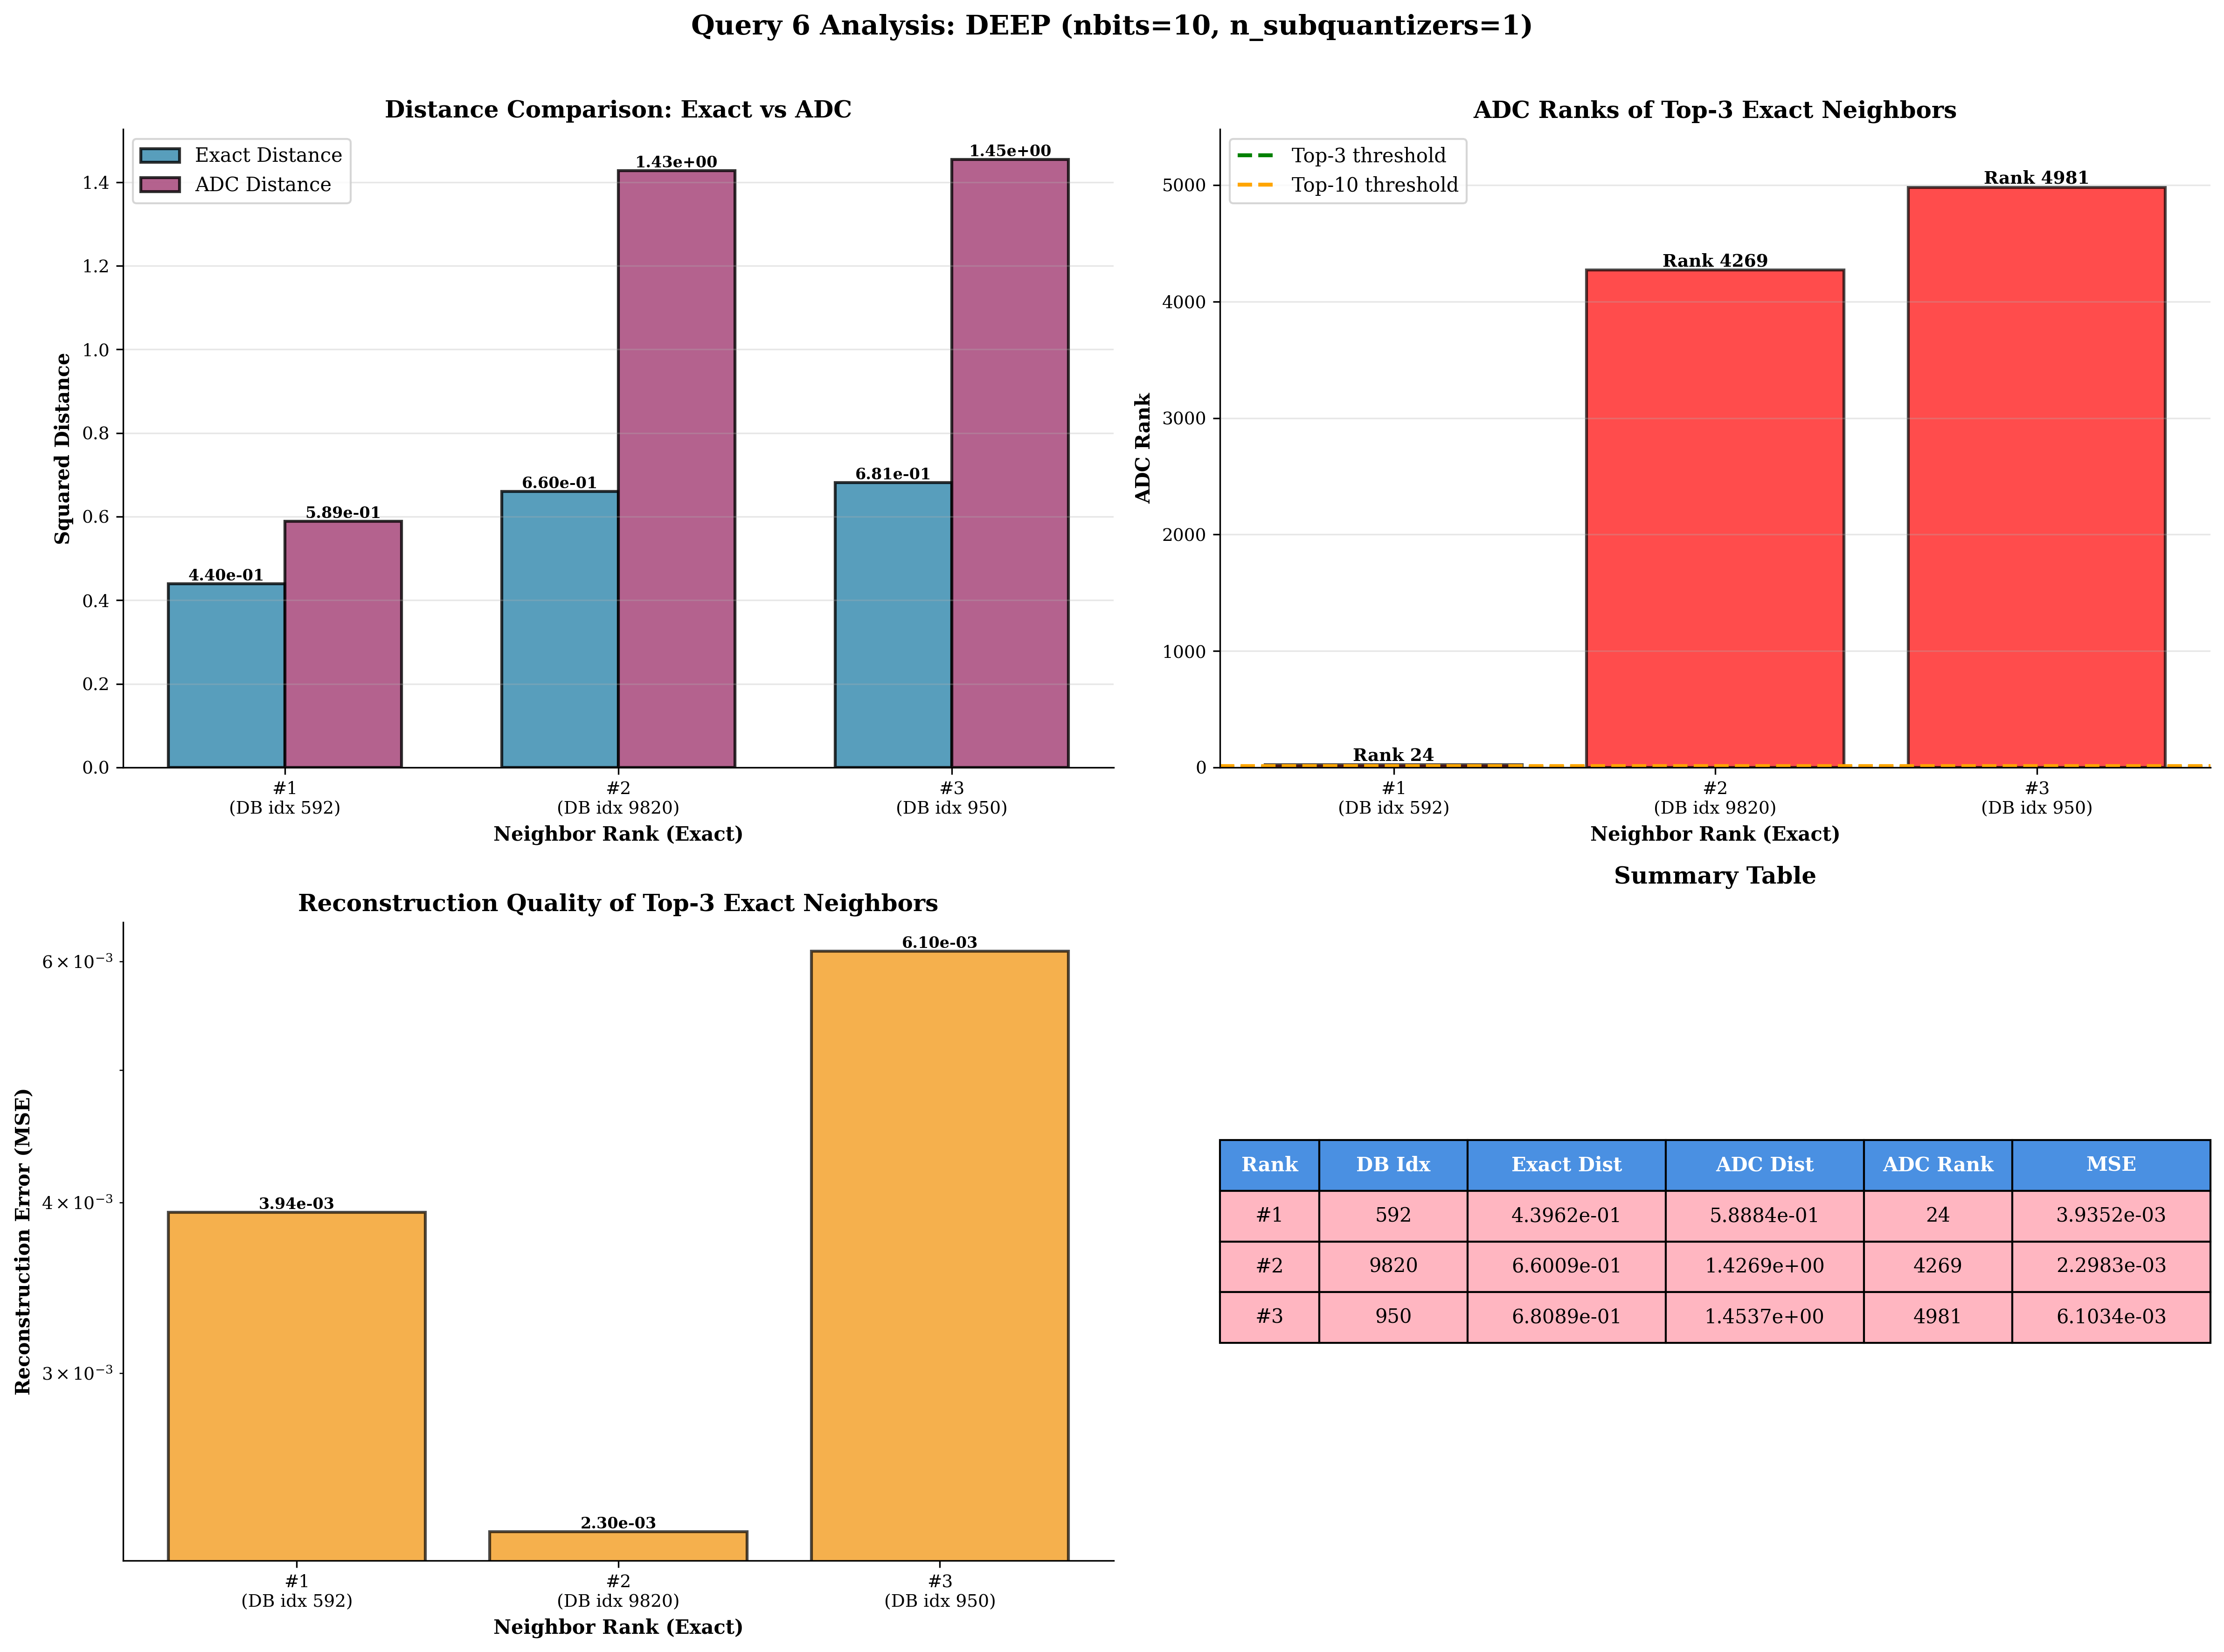


DETAILED SUMMARY
Query index: 6
Database: TEST (10000 vectors)
Experiment: subq1_nbits10_train100000000_20251211_175442

Top-3 Exact Neighbors:

  Rank 1 (Database vector 592):
    Exact distance: 4.396157e-01
    ADC distance: 5.888353e-01
    ADC rank: 24/10000
    Reconstruction MSE: 3.935228e-03

  Rank 2 (Database vector 9820):
    Exact distance: 6.600948e-01
    ADC distance: 1.426939e+00
    ADC rank: 4269/10000
    Reconstruction MSE: 2.298267e-03

  Rank 3 (Database vector 950):
    Exact distance: 6.808903e-01
    ADC distance: 1.453703e+00
    ADC rank: 4981/10000
    Reconstruction MSE: 6.103426e-03


In [9]:
# ============================================================================
# Per-Query Analysis: Top-3 Ground Truth Neighbors, ADC Ranks, and Reconstruction Quality
# ============================================================================

# ============================================================================
# CONFIGURATION
# ============================================================================

# Choose which experiment to analyze (from the CSV)
dataset_name = 'deep'  # 'gist', 'deep', or 'glove'
nbits_val = 10
n_subquantizers_val = 1

# Choose query index (0 to 999, since we use 1000 queries)
query_idx = np.random.randint(0, 1000)

# Choose database: 'test', 'train', or provide a custom path
# - 'test': uses dataset_path (test database)
# - 'train': uses train_path (training database)  
# - Custom path: provide full path as string, e.g., '/path/to/database.bin'
database_type = 'test'  # Change to 'train', or provide custom path as string

# Number of database vectors to use
n_db_vectors = 10000

# Number of top neighbors to show
top_k = 3

# ============================================================================
# Load experiment and data
# ============================================================================

# Find the experiment in CSV
config = dataset_config[dataset_name]
df = dataframes[dataset_name]

# Filter to find the experiment
experiment_row = df[
    (df['nbits'] == nbits_val) & 
    (df['n_subquantizers'] == n_subquantizers_val) &
    (df['train_size'] == config['train_size'])
].iloc[0] if len(df[
    (df['nbits'] == nbits_val) & 
    (df['n_subquantizers'] == n_subquantizers_val) &
    (df['train_size'] == config['train_size'])
]) > 0 else None

if experiment_row is None:
    raise ValueError(f"No experiment found for {dataset_name} with nbits={nbits_val}, n_subquantizers={n_subquantizers_val}")

experiment_folder = Path(experiment_row['experiment_folder'])
model_path = experiment_folder / 'pq_model.index'

if not model_path.exists():
    raise FileNotFoundError(f"Model not found: {model_path}")

print(f"Loading experiment: {experiment_folder.name}")
print(f"  Dataset: {dataset_name.upper()}")
print(f"  nbits: {nbits_val}, n_subquantizers: {n_subquantizers_val}")

# Load PQ model
pq_index = faiss.read_index(str(model_path))
pq = pq_index.pq
dim = pq.d

# Load queries
queries, _ = load_dataset(
    config['query_path'],
    None,
    config['dim'],
    db_chunk_size=None,
    qr_chunk_size=1000
)

if query_idx >= len(queries):
    raise ValueError(f"Query index {query_idx} out of range (max: {len(queries)-1})")

query = queries[query_idx:query_idx+1]  # Keep as 2D array
print(f"\nSelected query {query_idx}")

# Load database (test, train, or custom path)
if database_type == 'test':
    db_path = config['dataset_path']
    print(f"Loading TEST database from: {db_path}")
elif database_type == 'train':
    # Need to find train_path - check if it's in config or construct it
    if 'train_path' in config:
        db_path = config['train_path']
    else:
        # Try to construct train path (common pattern)
        base_path = Path(config['dataset_path']).parent
        # This is a guess - user may need to adjust
        db_path = str(base_path / 'train.bin')
        print(f"⚠️  Warning: train_path not in config, trying: {db_path}")
    print(f"Loading TRAIN database from: {db_path}")
else:
    # Custom path provided
    db_path = database_type
    print(f"Loading CUSTOM database from: {db_path}")

database, _ = load_dataset(
    db_path,
    None,
    config['dim'],
    db_chunk_size=n_db_vectors,
    qr_chunk_size=None
)

database = database[:n_db_vectors]  # Ensure we only use first n_db_vectors
print(f"Loaded {len(database)} database vectors")

# ============================================================================
# Compute distances and rankings
# ============================================================================

# Compute exact distances
print("\nComputing exact distances...")
exact_distances = cdist(query, database, metric="sqeuclidean")[0]  # [0] to get 1D array
exact_ranks = np.argsort(exact_distances)

# Get top-k exact neighbors
top_k_exact_indices = exact_ranks[:top_k]
top_k_exact_distances = exact_distances[top_k_exact_indices]

print(f"\nTop-{top_k} exact neighbors:")
for i, (idx, dist) in enumerate(zip(top_k_exact_indices, top_k_exact_distances)):
    print(f"  Rank {i+1}: Database vector {idx}, distance = {dist:.6f}")

# Encode database and compute ADC distances
print("\nEncoding database and computing ADC distances...")
codes = pq.compute_codes(database)

# Compute distance tables for the query
ksub = 1 << nbits_val
centroids = faiss.vector_to_array(pq.centroids).reshape(n_subquantizers_val, ksub, dim // n_subquantizers_val)
dis_table = compute_distance_tables_vectorized(query, centroids, n_subquantizers_val, ksub, dim)[0]  # [0] for single query

# Compute ADC distances
adc_distances = adc_distances_batch_numba(dis_table[np.newaxis, :], codes, n_subquantizers_val)[0]  # [0] for single query
adc_ranks = np.argsort(adc_distances)

# Find ranks of top-k exact neighbors in ADC ranking
print(f"\nADC ranks of top-{top_k} exact neighbors:")
for i, exact_idx in enumerate(top_k_exact_indices):
    adc_rank = np.where(adc_ranks == exact_idx)[0][0] + 1  # +1 for 1-indexed
    exact_dist = exact_distances[exact_idx]
    adc_dist = adc_distances[exact_idx]
    print(f"  Exact neighbor {i+1} (DB idx {exact_idx}):")
    print(f"    Exact distance: {exact_dist:.6f}")
    print(f"    ADC distance: {adc_dist:.6f}")
    print(f"    ADC rank: {adc_rank}/{len(database)}")

# ============================================================================
# Compute reconstruction errors
# ============================================================================

print("\nComputing reconstruction errors for top-k exact neighbors...")
# Reconstruct vectors for top-k exact neighbors
temp_index = faiss.IndexPQ(pq.d, pq.M, pq.nbits)
temp_index.pq = pq
reconstructed_all = temp_index.sa_decode(codes)

# Compute MSE per vector
mse_per_vector = np.mean((database - reconstructed_all) ** 2, axis=1)

print(f"\nReconstruction errors (MSE) for top-{top_k} exact neighbors:")
for i, exact_idx in enumerate(top_k_exact_indices):
    mse = mse_per_vector[exact_idx]
    print(f"  Exact neighbor {i+1} (DB idx {exact_idx}): MSE = {mse:.6e}")

# ============================================================================
# Visualization
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f'Query {query_idx} Analysis: {dataset_name.upper()} (nbits={nbits_val}, n_subquantizers={n_subquantizers_val})', 
             fontsize=14, fontweight='bold')

# Plot 1: Distance comparison (exact vs ADC) for top-k exact neighbors
ax1 = axes[0, 0]
x_pos = np.arange(top_k)
width = 0.35
exact_dists_plot = exact_distances[top_k_exact_indices]
adc_dists_plot = adc_distances[top_k_exact_indices]

bars1 = ax1.bar(x_pos - width/2, exact_dists_plot, width, label='Exact Distance', 
                color='#2E86AB', alpha=0.8, edgecolor='black', linewidth=1.5)
bars2 = ax1.bar(x_pos + width/2, adc_dists_plot, width, label='ADC Distance', 
                color='#A23B72', alpha=0.8, edgecolor='black', linewidth=1.5)

ax1.set_xlabel('Neighbor Rank (Exact)', fontweight='bold')
ax1.set_ylabel('Squared Distance', fontweight='bold')
ax1.set_title('Distance Comparison: Exact vs ADC', fontsize=12, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels([f'#{i+1}\n(DB idx {idx})' for i, idx in enumerate(top_k_exact_indices)])
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2e}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# Plot 2: ADC ranks of top-k exact neighbors
ax2 = axes[0, 1]
adc_ranks_list = [np.where(adc_ranks == idx)[0][0] + 1 for idx in top_k_exact_indices]
colors_rank = ['green' if r <= top_k else 'orange' if r <= 10 else 'red' for r in adc_ranks_list]

bars = ax2.bar(range(top_k), adc_ranks_list, color=colors_rank, alpha=0.7, 
               edgecolor='black', linewidth=1.5)
ax2.set_xlabel('Neighbor Rank (Exact)', fontweight='bold')
ax2.set_ylabel('ADC Rank', fontweight='bold')
ax2.set_title(f'ADC Ranks of Top-{top_k} Exact Neighbors', fontsize=12, fontweight='bold')
ax2.set_xticks(range(top_k))
ax2.set_xticklabels([f'#{i+1}\n(DB idx {idx})' for i, idx in enumerate(top_k_exact_indices)])
ax2.axhline(y=top_k, color='green', linestyle='--', linewidth=2, label=f'Top-{top_k} threshold')
ax2.axhline(y=10, color='orange', linestyle='--', linewidth=2, label='Top-10 threshold')
ax2.set_ylim(0, max(adc_ranks_list) * 1.1)
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (bar, rank) in enumerate(zip(bars, adc_ranks_list)):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'Rank {rank}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Plot 3: Reconstruction errors (MSE) for top-k exact neighbors
ax3 = axes[1, 0]
mse_values = mse_per_vector[top_k_exact_indices]
bars = ax3.bar(range(top_k), mse_values, color='#F18F01', alpha=0.7, 
               edgecolor='black', linewidth=1.5)
ax3.set_xlabel('Neighbor Rank (Exact)', fontweight='bold')
ax3.set_ylabel('Reconstruction Error (MSE)', fontweight='bold')
ax3.set_title(f'Reconstruction Quality of Top-{top_k} Exact Neighbors', fontsize=12, fontweight='bold')
ax3.set_xticks(range(top_k))
ax3.set_xticklabels([f'#{i+1}\n(DB idx {idx})' for i, idx in enumerate(top_k_exact_indices)])
ax3.set_yscale('log')
ax3.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (bar, mse) in enumerate(zip(bars, mse_values)):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{mse:.2e}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# Plot 4: Summary table visualization
ax4 = axes[1, 1]
ax4.axis('off')

# Create summary table
table_data = []
headers = ['Rank', 'DB Idx', 'Exact Dist', 'ADC Dist', 'ADC Rank', 'MSE']
for i, exact_idx in enumerate(top_k_exact_indices):
    adc_rank = np.where(adc_ranks == exact_idx)[0][0] + 1
    row = [
        f'#{i+1}',
        str(exact_idx),
        f'{exact_distances[exact_idx]:.4e}',
        f'{adc_distances[exact_idx]:.4e}',
        str(adc_rank),
        f'{mse_per_vector[exact_idx]:.4e}'
    ]
    table_data.append(row)

table = ax4.table(cellText=table_data, colLabels=headers, 
                  cellLoc='center', loc='center',
                  colWidths=[0.1, 0.15, 0.2, 0.2, 0.15, 0.2])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

# Style header row
for i in range(len(headers)):
    table[(0, i)].set_facecolor('#4A90E2')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Style data rows - color code by ADC rank
for i, exact_idx in enumerate(top_k_exact_indices):
    adc_rank = np.where(adc_ranks == exact_idx)[0][0] + 1
    row_idx = i + 1
    if adc_rank <= top_k:
        row_color = '#90EE90'  # Light green
    elif adc_rank <= 10:
        row_color = '#FFE4B5'  # Light orange
    else:
        row_color = '#FFB6C1'  # Light red
    
    for j in range(len(headers)):
        table[(row_idx, j)].set_facecolor(row_color)

ax4.set_title('Summary Table', fontsize=12, fontweight='bold', pad=20)

plt.tight_layout(rect=[0, 0, 1, 0.97])

# Save figure as PDF with descriptive filename
# Create output directory if it doesn't exist
output_dir = Path('/home/cpanourg/projects/2-hdvc/notebooks/general_results/figures')
output_dir.mkdir(parents=True, exist_ok=True)

# Create filename with parameters
db_type_str = database_type if database_type in ['test', 'train'] else 'custom'
filename = f"/mnthdd/cpanourg/2-hdvc/results/relerr/query_analysis_{dataset_name}_q{query_idx}_nbits{nbits_val}_nsubq{n_subquantizers_val}_db{db_type_str}_top{top_k}.pdf"
filepath = output_dir / filename

# Save figure
fig.savefig(filepath, format='pdf', bbox_inches='tight', dpi=300)
print(f"\n✅ Figure saved to: {filepath}")

plt.show()

# Print detailed summary
print("\n" + "="*70)
print("DETAILED SUMMARY")
print("="*70)
print(f"Query index: {query_idx}")
print(f"Database: {database_type.upper()} ({len(database)} vectors)")
print(f"Experiment: {experiment_folder.name}")
print(f"\nTop-{top_k} Exact Neighbors:")
for i, exact_idx in enumerate(top_k_exact_indices):
    adc_rank = np.where(adc_ranks == exact_idx)[0][0] + 1
    exact_dist = exact_distances[exact_idx]
    adc_dist = adc_distances[exact_idx]
    mse = mse_per_vector[exact_idx]
    print(f"\n  Rank {i+1} (Database vector {exact_idx}):")
    print(f"    Exact distance: {exact_dist:.6e}")
    print(f"    ADC distance: {adc_dist:.6e}")
    print(f"    ADC rank: {adc_rank}/{len(database)}")
    print(f"    Reconstruction MSE: {mse:.6e}")



Loading experiment: subq1_nbits8_train100000000_20251211_175303
  Dataset: DEEP
  nbits: 8, n_subquantizers: 1

Selected query 6
Loading TEST database from: /mnthdd/cpanourg/2-hdvc/data/deep1b/dataset/test_1m.bin
Loaded 10000 database vectors

Computing exact distances...

Top-3 exact neighbors:
  Rank 1: Database vector 592, distance = 0.439616
  Rank 2: Database vector 9820, distance = 0.660095
  Rank 3: Database vector 950, distance = 0.680890

Encoding database and computing ADC distances...

ADC ranks of top-3 exact neighbors:
  Exact neighbor 1 (DB idx 592):
    Exact distance: 0.439616
    ADC distance: 0.615563
    ADC rank: 69/10000
  Exact neighbor 2 (DB idx 9820):
    Exact distance: 0.660095
    ADC distance: 0.537613
    ADC rank: 34/10000
  Exact neighbor 3 (DB idx 950):
    Exact distance: 0.680890
    ADC distance: 0.615563
    ADC rank: 73/10000

Computing reconstruction errors for top-k exact neighbors...

Reconstruction errors (MSE) for top-3 exact neighbors:
  Exact

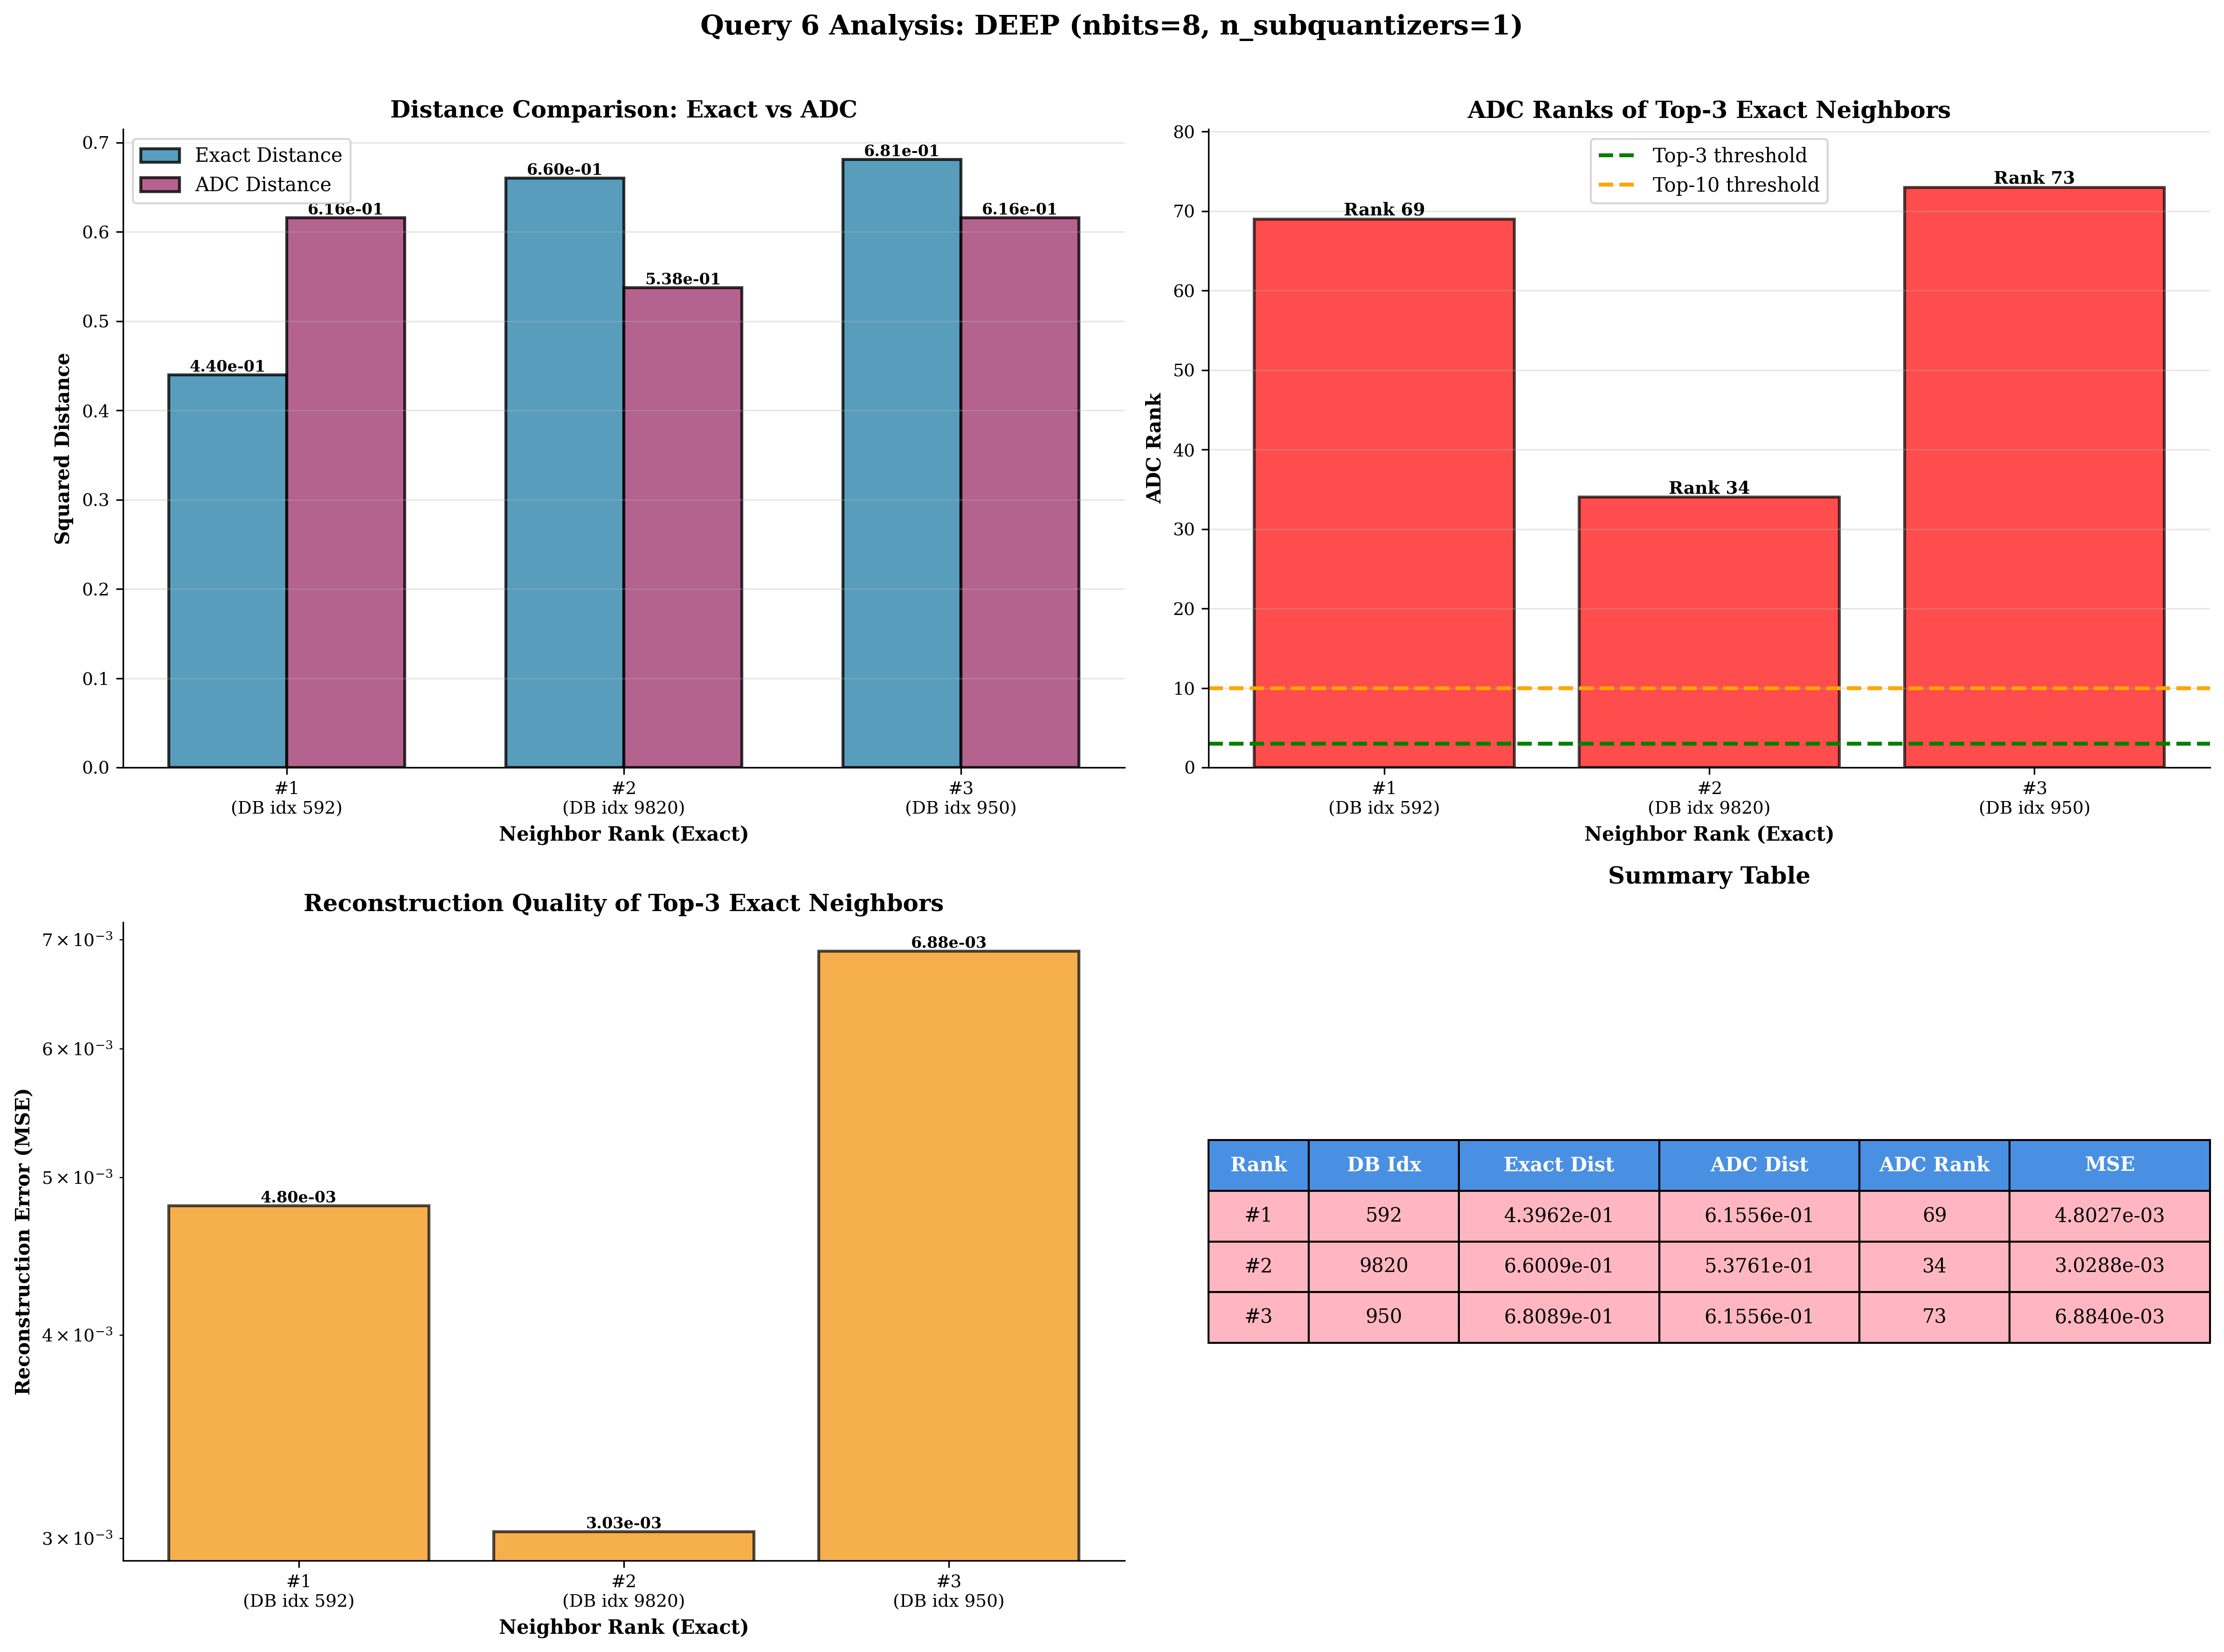


DETAILED SUMMARY
Query index: 6
Database: TEST (10000 vectors)
Experiment: subq1_nbits8_train100000000_20251211_175303

Top-3 Exact Neighbors:

  Rank 1 (Database vector 592):
    Exact distance: 4.396157e-01
    ADC distance: 6.155626e-01
    ADC rank: 69/10000
    Reconstruction MSE: 4.802702e-03

  Rank 2 (Database vector 9820):
    Exact distance: 6.600948e-01
    ADC distance: 5.376126e-01
    ADC rank: 34/10000
    Reconstruction MSE: 3.028840e-03

  Rank 3 (Database vector 950):
    Exact distance: 6.808903e-01
    ADC distance: 6.155626e-01
    ADC rank: 73/10000
    Reconstruction MSE: 6.884036e-03


In [10]:
# ============================================================================
# Per-Query Analysis: Top-3 Ground Truth Neighbors, ADC Ranks, and Reconstruction Quality
# ============================================================================

# ============================================================================
# CONFIGURATION
# ============================================================================

# Choose which experiment to analyze (from the CSV)
dataset_name = 'deep'  # 'gist', 'deep', or 'glove'
nbits_val = 8
# n_subquantizers_val = 24

# Choose query index (0 to 999, since we use 1000 queries)
# query_idx = 1 #np.random.randint(0, 1000)

# Choose database: 'test', 'train', or provide a custom path
# - 'test': uses dataset_path (test database)
# - 'train': uses train_path (training database)  
# - Custom path: provide full path as string, e.g., '/path/to/database.bin'
database_type = 'test'  # Change to 'train', or provide custom path as string

# Number of database vectors to use
n_db_vectors = 10000

# Number of top neighbors to show
top_k = 3

# ============================================================================
# Load experiment and data
# ============================================================================

# Find the experiment in CSV
config = dataset_config[dataset_name]
df = dataframes[dataset_name]

# Filter to find the experiment
experiment_row = df[
    (df['nbits'] == nbits_val) & 
    (df['n_subquantizers'] == n_subquantizers_val) &
    (df['train_size'] == config['train_size'])
].iloc[0] if len(df[
    (df['nbits'] == nbits_val) & 
    (df['n_subquantizers'] == n_subquantizers_val) &
    (df['train_size'] == config['train_size'])
]) > 0 else None

if experiment_row is None:
    raise ValueError(f"No experiment found for {dataset_name} with nbits={nbits_val}, n_subquantizers={n_subquantizers_val}")

experiment_folder = Path(experiment_row['experiment_folder'])
model_path = experiment_folder / 'pq_model.index'

if not model_path.exists():
    raise FileNotFoundError(f"Model not found: {model_path}")

print(f"Loading experiment: {experiment_folder.name}")
print(f"  Dataset: {dataset_name.upper()}")
print(f"  nbits: {nbits_val}, n_subquantizers: {n_subquantizers_val}")

# Load PQ model
pq_index = faiss.read_index(str(model_path))
pq = pq_index.pq
dim = pq.d

# Load queries
queries, _ = load_dataset(
    config['query_path'],
    None,
    config['dim'],
    db_chunk_size=None,
    qr_chunk_size=1000
)

if query_idx >= len(queries):
    raise ValueError(f"Query index {query_idx} out of range (max: {len(queries)-1})")

query = queries[query_idx:query_idx+1]  # Keep as 2D array
print(f"\nSelected query {query_idx}")

# Load database (test, train, or custom path)
if database_type == 'test':
    db_path = config['dataset_path']
    print(f"Loading TEST database from: {db_path}")
elif database_type == 'train':
    # Need to find train_path - check if it's in config or construct it
    if 'train_path' in config:
        db_path = config['train_path']
    else:
        # Try to construct train path (common pattern)
        base_path = Path(config['dataset_path']).parent
        # This is a guess - user may need to adjust
        db_path = str(base_path / 'train.bin')
        print(f"⚠️  Warning: train_path not in config, trying: {db_path}")
    print(f"Loading TRAIN database from: {db_path}")
else:
    # Custom path provided
    db_path = database_type
    print(f"Loading CUSTOM database from: {db_path}")

database, _ = load_dataset(
    db_path,
    None,
    config['dim'],
    db_chunk_size=n_db_vectors,
    qr_chunk_size=None
)

database = database[:n_db_vectors]  # Ensure we only use first n_db_vectors
print(f"Loaded {len(database)} database vectors")

# ============================================================================
# Compute distances and rankings
# ============================================================================

# Compute exact distances
print("\nComputing exact distances...")
exact_distances = cdist(query, database, metric="sqeuclidean")[0]  # [0] to get 1D array
exact_ranks = np.argsort(exact_distances)

# Get top-k exact neighbors
top_k_exact_indices = exact_ranks[:top_k]
top_k_exact_distances = exact_distances[top_k_exact_indices]

print(f"\nTop-{top_k} exact neighbors:")
for i, (idx, dist) in enumerate(zip(top_k_exact_indices, top_k_exact_distances)):
    print(f"  Rank {i+1}: Database vector {idx}, distance = {dist:.6f}")

# Encode database and compute ADC distances
print("\nEncoding database and computing ADC distances...")
codes = pq.compute_codes(database)

# Compute distance tables for the query
ksub = 1 << nbits_val
centroids = faiss.vector_to_array(pq.centroids).reshape(n_subquantizers_val, ksub, dim // n_subquantizers_val)
dis_table = compute_distance_tables_vectorized(query, centroids, n_subquantizers_val, ksub, dim)[0]  # [0] for single query

# Compute ADC distances
adc_distances = adc_distances_batch_numba(dis_table[np.newaxis, :], codes, n_subquantizers_val)[0]  # [0] for single query
adc_ranks = np.argsort(adc_distances)

# Find ranks of top-k exact neighbors in ADC ranking
print(f"\nADC ranks of top-{top_k} exact neighbors:")
for i, exact_idx in enumerate(top_k_exact_indices):
    adc_rank = np.where(adc_ranks == exact_idx)[0][0] + 1  # +1 for 1-indexed
    exact_dist = exact_distances[exact_idx]
    adc_dist = adc_distances[exact_idx]
    print(f"  Exact neighbor {i+1} (DB idx {exact_idx}):")
    print(f"    Exact distance: {exact_dist:.6f}")
    print(f"    ADC distance: {adc_dist:.6f}")
    print(f"    ADC rank: {adc_rank}/{len(database)}")

# ============================================================================
# Compute reconstruction errors
# ============================================================================

print("\nComputing reconstruction errors for top-k exact neighbors...")
# Reconstruct vectors for top-k exact neighbors
temp_index = faiss.IndexPQ(pq.d, pq.M, pq.nbits)
temp_index.pq = pq
reconstructed_all = temp_index.sa_decode(codes)

# Compute MSE per vector
mse_per_vector = np.mean((database - reconstructed_all) ** 2, axis=1)

print(f"\nReconstruction errors (MSE) for top-{top_k} exact neighbors:")
for i, exact_idx in enumerate(top_k_exact_indices):
    mse = mse_per_vector[exact_idx]
    print(f"  Exact neighbor {i+1} (DB idx {exact_idx}): MSE = {mse:.6e}")

# ============================================================================
# Visualization
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f'Query {query_idx} Analysis: {dataset_name.upper()} (nbits={nbits_val}, n_subquantizers={n_subquantizers_val})', 
             fontsize=14, fontweight='bold')

# Plot 1: Distance comparison (exact vs ADC) for top-k exact neighbors
ax1 = axes[0, 0]
x_pos = np.arange(top_k)
width = 0.35
exact_dists_plot = exact_distances[top_k_exact_indices]
adc_dists_plot = adc_distances[top_k_exact_indices]

bars1 = ax1.bar(x_pos - width/2, exact_dists_plot, width, label='Exact Distance', 
                color='#2E86AB', alpha=0.8, edgecolor='black', linewidth=1.5)
bars2 = ax1.bar(x_pos + width/2, adc_dists_plot, width, label='ADC Distance', 
                color='#A23B72', alpha=0.8, edgecolor='black', linewidth=1.5)

ax1.set_xlabel('Neighbor Rank (Exact)', fontweight='bold')
ax1.set_ylabel('Squared Distance', fontweight='bold')
ax1.set_title('Distance Comparison: Exact vs ADC', fontsize=12, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels([f'#{i+1}\n(DB idx {idx})' for i, idx in enumerate(top_k_exact_indices)])
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2e}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# Plot 2: ADC ranks of top-k exact neighbors
ax2 = axes[0, 1]
adc_ranks_list = [np.where(adc_ranks == idx)[0][0] + 1 for idx in top_k_exact_indices]
colors_rank = ['green' if r <= top_k else 'orange' if r <= 10 else 'red' for r in adc_ranks_list]

bars = ax2.bar(range(top_k), adc_ranks_list, color=colors_rank, alpha=0.7, 
               edgecolor='black', linewidth=1.5)
ax2.set_xlabel('Neighbor Rank (Exact)', fontweight='bold')
ax2.set_ylabel('ADC Rank', fontweight='bold')
ax2.set_title(f'ADC Ranks of Top-{top_k} Exact Neighbors', fontsize=12, fontweight='bold')
ax2.set_xticks(range(top_k))
ax2.set_xticklabels([f'#{i+1}\n(DB idx {idx})' for i, idx in enumerate(top_k_exact_indices)])
ax2.axhline(y=top_k, color='green', linestyle='--', linewidth=2, label=f'Top-{top_k} threshold')
ax2.axhline(y=10, color='orange', linestyle='--', linewidth=2, label='Top-10 threshold')
ax2.set_ylim(0, max(adc_ranks_list) * 1.1)
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (bar, rank) in enumerate(zip(bars, adc_ranks_list)):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'Rank {rank}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Plot 3: Reconstruction errors (MSE) for top-k exact neighbors
ax3 = axes[1, 0]
mse_values = mse_per_vector[top_k_exact_indices]
bars = ax3.bar(range(top_k), mse_values, color='#F18F01', alpha=0.7, 
               edgecolor='black', linewidth=1.5)
ax3.set_xlabel('Neighbor Rank (Exact)', fontweight='bold')
ax3.set_ylabel('Reconstruction Error (MSE)', fontweight='bold')
ax3.set_title(f'Reconstruction Quality of Top-{top_k} Exact Neighbors', fontsize=12, fontweight='bold')
ax3.set_xticks(range(top_k))
ax3.set_xticklabels([f'#{i+1}\n(DB idx {idx})' for i, idx in enumerate(top_k_exact_indices)])
ax3.set_yscale('log')
ax3.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (bar, mse) in enumerate(zip(bars, mse_values)):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{mse:.2e}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# Plot 4: Summary table visualization
ax4 = axes[1, 1]
ax4.axis('off')

# Create summary table
table_data = []
headers = ['Rank', 'DB Idx', 'Exact Dist', 'ADC Dist', 'ADC Rank', 'MSE']
for i, exact_idx in enumerate(top_k_exact_indices):
    adc_rank = np.where(adc_ranks == exact_idx)[0][0] + 1
    row = [
        f'#{i+1}',
        str(exact_idx),
        f'{exact_distances[exact_idx]:.4e}',
        f'{adc_distances[exact_idx]:.4e}',
        str(adc_rank),
        f'{mse_per_vector[exact_idx]:.4e}'
    ]
    table_data.append(row)

table = ax4.table(cellText=table_data, colLabels=headers, 
                  cellLoc='center', loc='center',
                  colWidths=[0.1, 0.15, 0.2, 0.2, 0.15, 0.2])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

# Style header row
for i in range(len(headers)):
    table[(0, i)].set_facecolor('#4A90E2')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Style data rows - color code by ADC rank
for i, exact_idx in enumerate(top_k_exact_indices):
    adc_rank = np.where(adc_ranks == exact_idx)[0][0] + 1
    row_idx = i + 1
    if adc_rank <= top_k:
        row_color = '#90EE90'  # Light green
    elif adc_rank <= 10:
        row_color = '#FFE4B5'  # Light orange
    else:
        row_color = '#FFB6C1'  # Light red
    
    for j in range(len(headers)):
        table[(row_idx, j)].set_facecolor(row_color)

ax4.set_title('Summary Table', fontsize=12, fontweight='bold', pad=20)

plt.tight_layout(rect=[0, 0, 1, 0.97])

# Save figure as PDF with descriptive filename
# Create output directory if it doesn't exist
output_dir = Path('/home/cpanourg/projects/2-hdvc/notebooks/general_results/figures')
output_dir.mkdir(parents=True, exist_ok=True)

# Create filename with parameters
db_type_str = database_type if database_type in ['test', 'train'] else 'custom'
filename = f"/mnthdd/cpanourg/2-hdvc/results/relerr/query_analysis_{dataset_name}_q{query_idx}_nbits{nbits_val}_nsubq{n_subquantizers_val}_db{db_type_str}_top{top_k}.pdf"
filepath = output_dir / filename

# Save figure
fig.savefig(filepath, format='pdf', bbox_inches='tight', dpi=300)
print(f"\n✅ Figure saved to: {filepath}")

plt.show()

# Print detailed summary
print("\n" + "="*70)
print("DETAILED SUMMARY")
print("="*70)
print(f"Query index: {query_idx}")
print(f"Database: {database_type.upper()} ({len(database)} vectors)")
print(f"Experiment: {experiment_folder.name}")
print(f"\nTop-{top_k} Exact Neighbors:")
for i, exact_idx in enumerate(top_k_exact_indices):
    adc_rank = np.where(adc_ranks == exact_idx)[0][0] + 1
    exact_dist = exact_distances[exact_idx]
    adc_dist = adc_distances[exact_idx]
    mse = mse_per_vector[exact_idx]
    print(f"\n  Rank {i+1} (Database vector {exact_idx}):")
    print(f"    Exact distance: {exact_dist:.6e}")
    print(f"    ADC distance: {adc_dist:.6e}")
    print(f"    ADC rank: {adc_rank}/{len(database)}")
    print(f"    Reconstruction MSE: {mse:.6e}")



Selected query 6
Query shape: (96,)

Processing nbits=8
Loading experiment: subq1_nbits8_train100000000_20251211_175303
  Dataset: DEEP
  nbits: 8, n_subquantizers: 1
Centroids shape: (1, 256, 96) (n_subquantizers=1, ksub=256, subspace_dim=96)

  Subspace 0: Applying t-SNE to 257 points...


OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.



✅ Figure saved to: /home/cpanourg/projects/2-hdvc/notebooks/general_results/figures/tsne_subspaces_deep_q6_nbits8_nsubq1.pdf


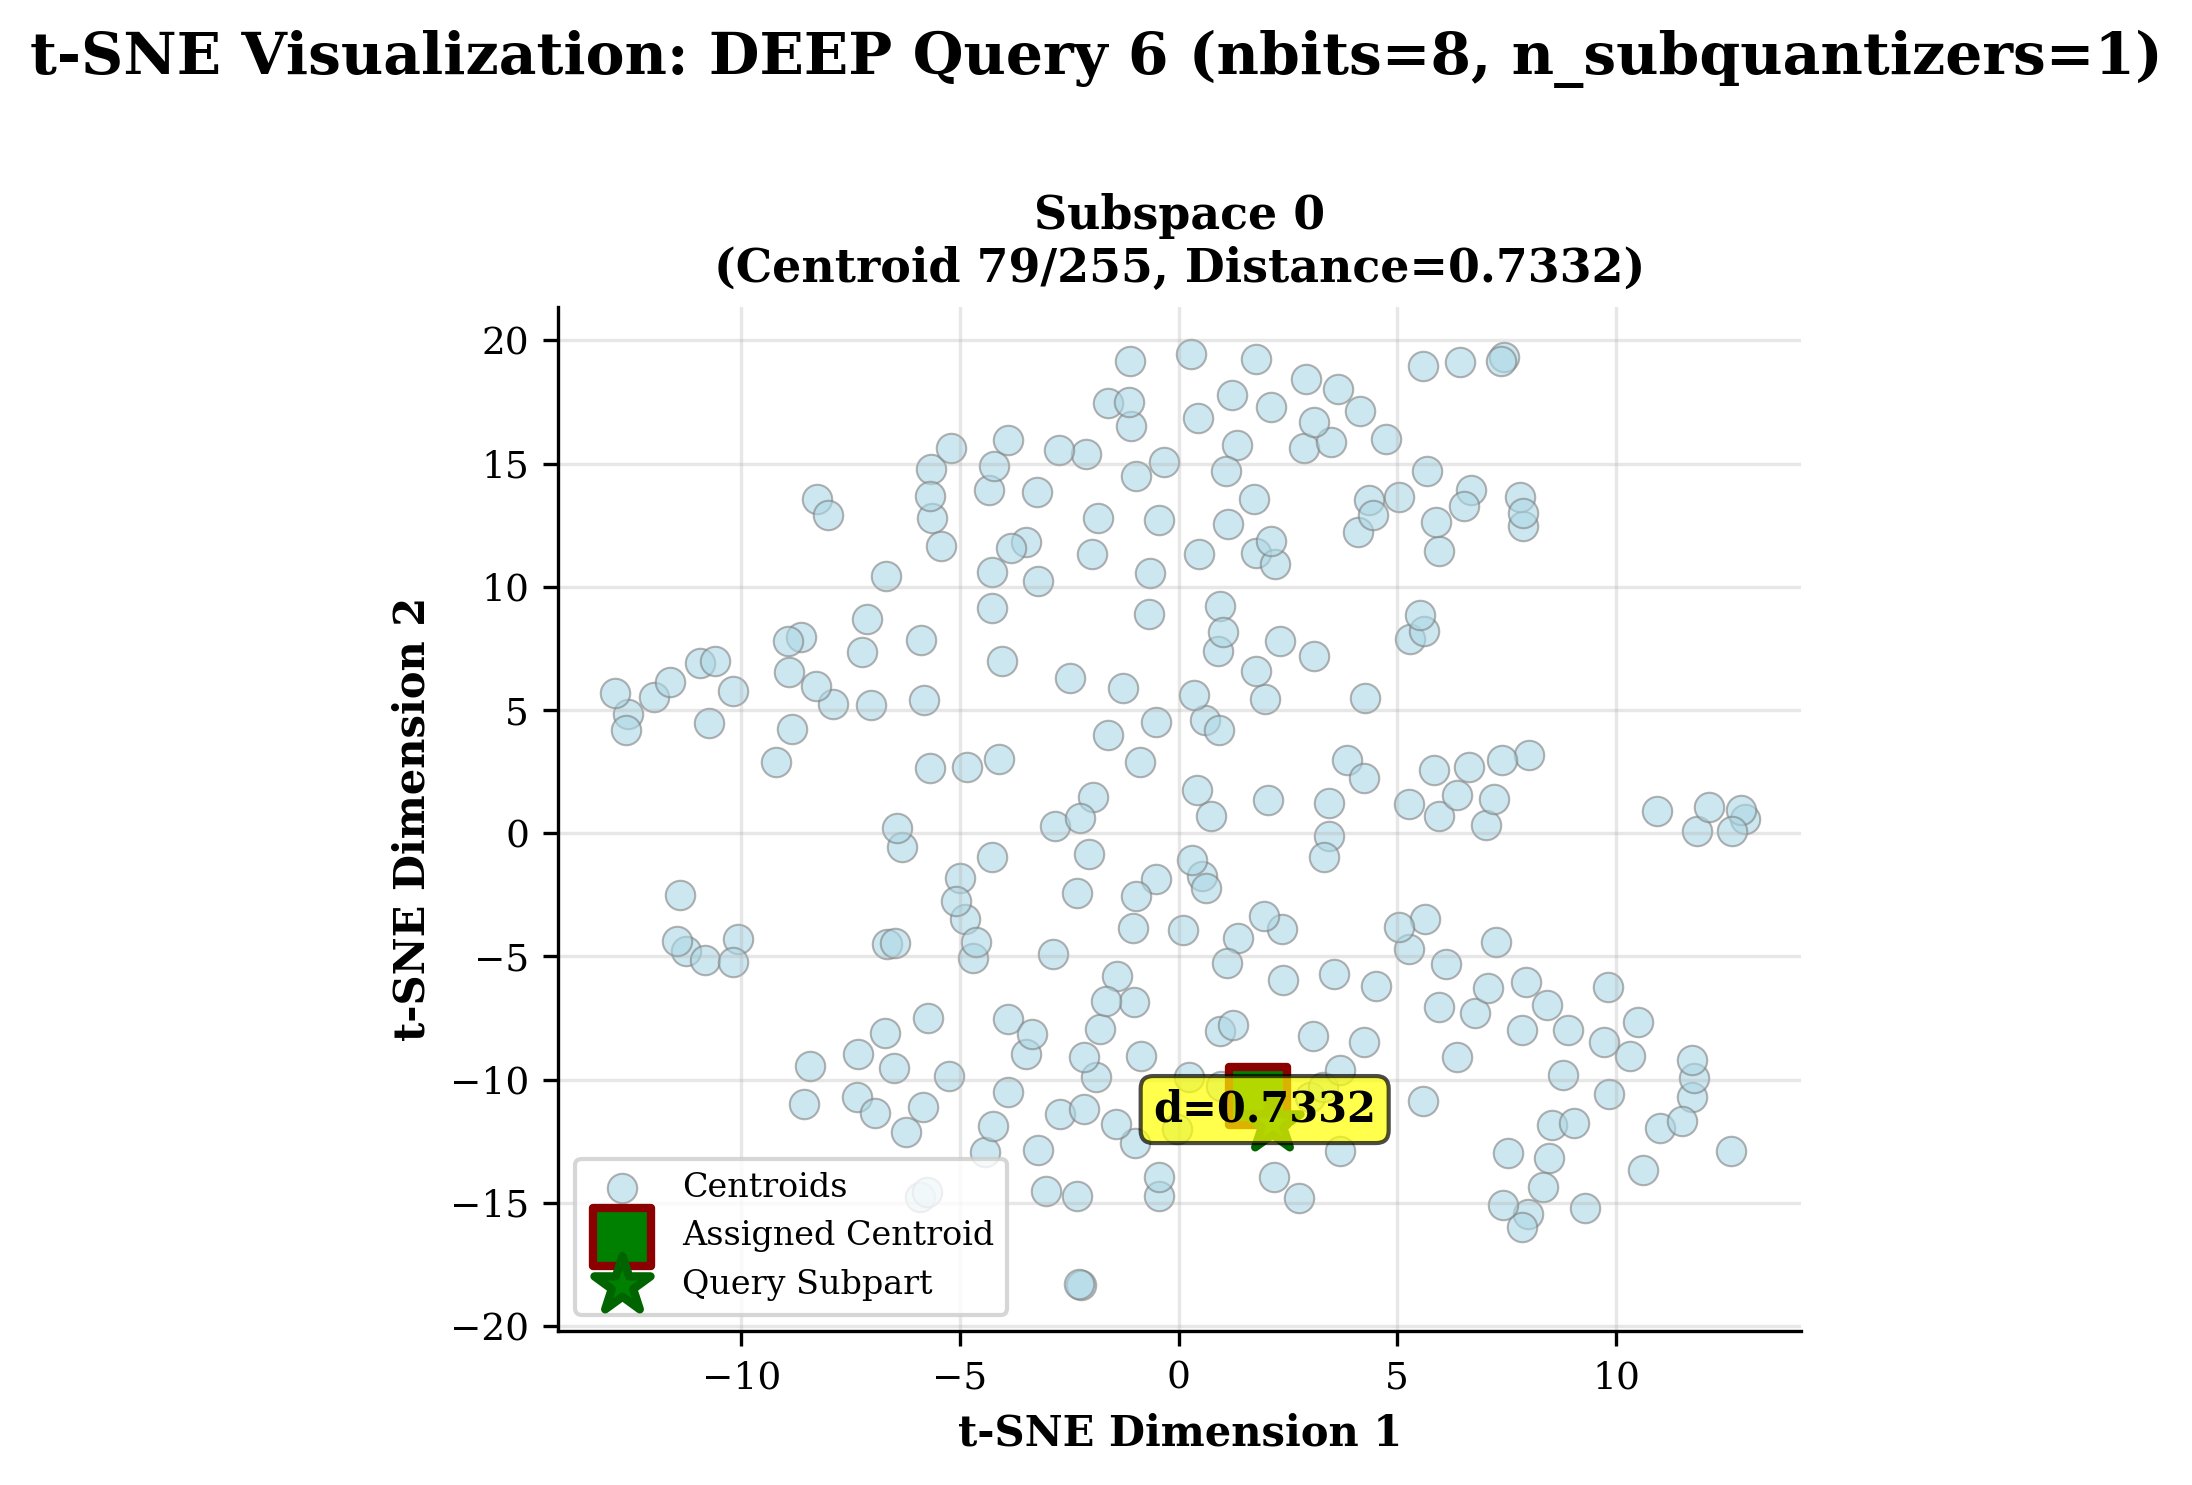


Summary for nbits=8
Query index: 6
Query codes: [79]

Subspace assignments:
  Subspace 0: Centroid 79, Distance = 0.733221

Processing nbits=10
Loading experiment: subq1_nbits10_train100000000_20251211_175442
  Dataset: DEEP
  nbits: 10, n_subquantizers: 1
Centroids shape: (1, 1024, 96) (n_subquantizers=1, ksub=1024, subspace_dim=96)

  Subspace 0: Applying t-SNE to 1025 points...


OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detec


✅ Figure saved to: /home/cpanourg/projects/2-hdvc/notebooks/general_results/figures/tsne_subspaces_deep_q6_nbits10_nsubq1.pdf


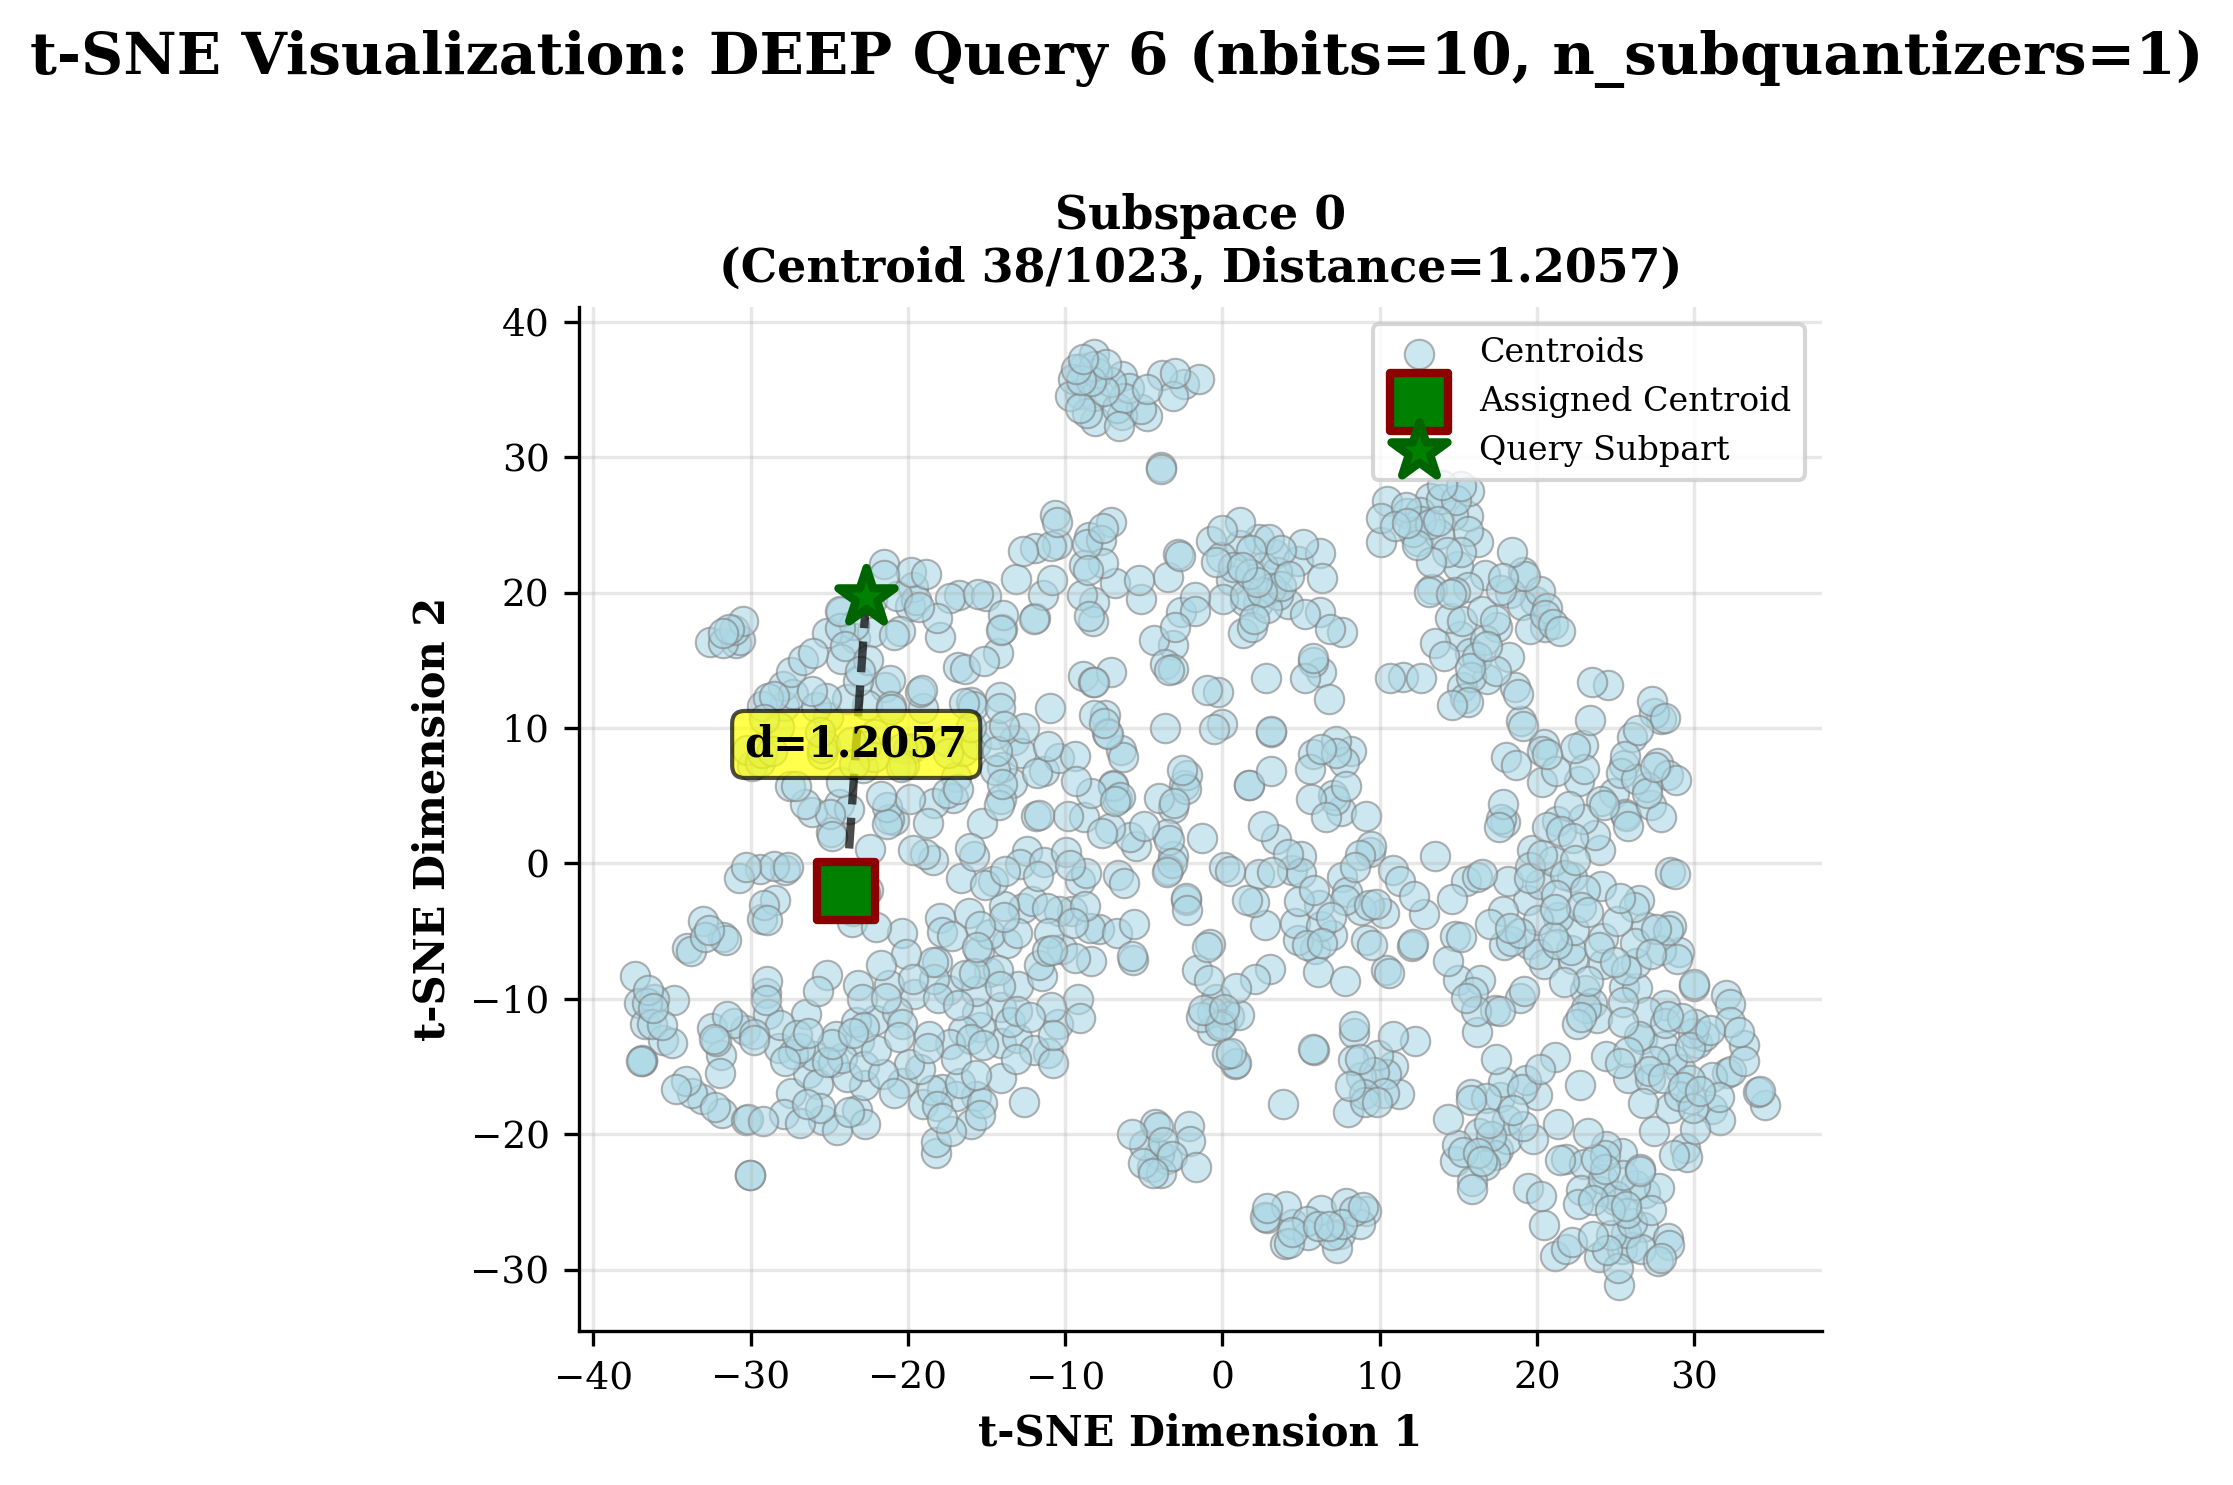


Summary for nbits=10
Query index: 6
Query codes: [38  2]

Subspace assignments:
  Subspace 0: Centroid 38, Distance = 1.205696

ALL NBITS VALUES PROCESSED


In [11]:
# ============================================================================
# t-SNE Visualization of PQ Subspaces
# ============================================================================
import os
os.environ["OPENBLAS_VERBOSE"] = "1"

from sklearn.manifold import TSNE
from scipy.spatial.distance import euclidean

# ============================================================================
# CONFIGURATION
# ============================================================================

# Choose dataset and subquantizer value
dataset_name = 'deep'  # 'gist', 'deep', or 'glove'
# n_subquantizers_val = 8  # Fixed subquantizer value

# List of nbits values to visualize
nbits_list = [8, 10]

# Choose query index (0 to 999, since we use 1000 queries)
# query_idx = 1  # Change this to visualize different queries

# Choose which subspaces to visualize (None = all, or list like [0, 1, 2] for first 3)
subspaces_to_plot = None  # None for all, or [0, 1, 2, ...] for specific subspaces

# t-SNE parameters
tsne_perplexity = 30
tsne_random_state = 42

# ============================================================================
# Load experiment and data
# ============================================================================

config = dataset_config[dataset_name]
df = dataframes[dataset_name]

# Load queries
queries, _ = load_dataset(
    config['query_path'],
    None,
    config['dim'],
    db_chunk_size=None,
    qr_chunk_size=1000
)

if query_idx >= len(queries):
    raise ValueError(f"Query index {query_idx} out of range (max: {len(queries)-1})")

query = queries[query_idx:query_idx+1][0]  # Get single query vector
print(f"Selected query {query_idx}")
print(f"Query shape: {query.shape}")

# Create output directory
output_dir = Path('/home/cpanourg/projects/2-hdvc/notebooks/general_results/figures')
output_dir.mkdir(parents=True, exist_ok=True)

# ============================================================================
# Process each nbits value
# ============================================================================

for nbits_val in nbits_list:
    print("\n" + "="*70)
    print(f"Processing nbits={nbits_val}")
    print("="*70)
    
    # Find the experiment in CSV
    experiment_row = df[
        (df['nbits'] == nbits_val) & 
        (df['n_subquantizers'] == n_subquantizers_val) &
        (df['train_size'] == config['train_size'])
    ].iloc[0] if len(df[
        (df['nbits'] == nbits_val) & 
        (df['n_subquantizers'] == n_subquantizers_val) &
        (df['train_size'] == config['train_size'])
    ]) > 0 else None
    
    if experiment_row is None:
        print(f"⚠️  Warning: No experiment found for {dataset_name} with nbits={nbits_val}, n_subquantizers={n_subquantizers_val}")
        print(f"   Skipping nbits={nbits_val}")
        continue
    
    experiment_folder = Path(experiment_row['experiment_folder'])
    model_path = experiment_folder / 'pq_model.index'
    
    if not model_path.exists():
        print(f"⚠️  Warning: Model not found: {model_path}")
        print(f"   Skipping nbits={nbits_val}")
        continue
    
    print(f"Loading experiment: {experiment_folder.name}")
    print(f"  Dataset: {dataset_name.upper()}")
    print(f"  nbits: {nbits_val}, n_subquantizers: {n_subquantizers_val}")
    
    # Load PQ model
    pq_index = faiss.read_index(str(model_path))
    pq = pq_index.pq
    dim = pq.d
    n_subquantizers = pq.M
    
    if n_subquantizers != n_subquantizers_val:
        print(f"⚠️  Warning: Model has {n_subquantizers} subquantizers, expected {n_subquantizers_val}")
        print(f"   Skipping nbits={nbits_val}")
        continue
    
    # Get centroids
    ksub = 1 << nbits_val  # 2^nbits
    centroids = faiss.vector_to_array(pq.centroids).reshape(n_subquantizers, ksub, dim // n_subquantizers)
    print(f"Centroids shape: {centroids.shape} (n_subquantizers={n_subquantizers}, ksub={ksub}, subspace_dim={dim // n_subquantizers})")
    
    # Determine which subspaces to plot
    subspaces = list(range(n_subquantizers)) if subspaces_to_plot is None else subspaces_to_plot
    
    # Compute query codes to find which centroids are used
    query_2d = query.reshape(1, -1)  # Reshape for faiss
    query_codes = pq.compute_codes(query_2d)[0]  # Get codes for the query
    
    # Split query into subspaces
    subspace_dim = dim // n_subquantizers
    query_subspaces = []
    for m in range(n_subquantizers):
        start_idx = m * subspace_dim
        end_idx = (m + 1) * subspace_dim
        query_subspaces.append(query[start_idx:end_idx])
    
    # ============================================================================
    # Create t-SNE visualization for each subspace
    # ============================================================================
    
    n_subspaces_to_plot = len(subspaces)
    n_cols = min(4, n_subspaces_to_plot)  # Max 4 columns
    n_rows = (n_subspaces_to_plot + n_cols - 1) // n_cols  # Ceiling division
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))
    fig.suptitle(f't-SNE Visualization: {dataset_name.upper()} Query {query_idx} (nbits={nbits_val}, n_subquantizers={n_subquantizers_val})', 
                 fontsize=14, fontweight='bold')
    
    # Flatten axes if needed
    if n_subspaces_to_plot == 1:
        axes = [axes]
    else:
        axes = axes.flatten() if n_rows > 1 else axes
    
    for plot_idx, m in enumerate(subspaces):
        ax = axes[plot_idx]
        
        # Get centroids for this subspace
        subspace_centroids = centroids[m]  # Shape: (ksub, subspace_dim)
        
        # Get query subpart for this subspace
        query_subpart = query_subspaces[m]  # Shape: (subspace_dim,)
        
        # Find which centroid is used (from query_codes)
        centroid_idx = query_codes[m]
        assigned_centroid = subspace_centroids[centroid_idx]  # Shape: (subspace_dim,)
        
        # Compute distance between query subpart and assigned centroid
        distance = euclidean(query_subpart, assigned_centroid)
        
        # Prepare data for t-SNE: centroids + query subpart
        # Stack centroids and query subpart
        data_for_tsne = np.vstack([subspace_centroids, query_subpart.reshape(1, -1)])
        
        # Apply t-SNE
        print(f"\n  Subspace {m}: Applying t-SNE to {data_for_tsne.shape[0]} points...")
        tsne = TSNE(n_components=2, perplexity=min(tsne_perplexity, data_for_tsne.shape[0] - 1), 
                   random_state=tsne_random_state, verbose=0)
        tsne_result = tsne.fit_transform(data_for_tsne)
        
        # Split back: last point is query, rest are centroids
        centroids_2d = tsne_result[:-1]
        query_2d = tsne_result[-1]
        assigned_centroid_2d = tsne_result[centroid_idx]
        
        # Plot all centroids
        ax.scatter(centroids_2d[:, 0], centroids_2d[:, 1], 
                  c='lightblue', s=50, alpha=0.6, edgecolors='gray', linewidths=0.5,
                  label='Centroids')
        
        # Highlight assigned centroid
        ax.scatter(assigned_centroid_2d[0], assigned_centroid_2d[1], 
                  c='green', s=200, marker='s', edgecolors='darkred', linewidths=2,
                  label='Assigned Centroid', zorder=5)
        
        # Plot query subpart
        ax.scatter(query_2d[0], query_2d[1], 
                  c='green', s=200, marker='*', edgecolors='darkgreen', linewidths=2,
                  label='Query Subpart', zorder=5)
        
        # Draw line connecting query subpart to assigned centroid
        ax.plot([query_2d[0], assigned_centroid_2d[0]], 
               [query_2d[1], assigned_centroid_2d[1]], 
               'k--', linewidth=2, alpha=0.7, zorder=3)
        
        # Add distance text near the midpoint of the line
        mid_x = (query_2d[0] + assigned_centroid_2d[0]) / 2
        mid_y = (query_2d[1] + assigned_centroid_2d[1]) / 2
        ax.text(mid_x, mid_y, f'd={distance:.4f}', 
               fontsize=10, fontweight='bold', 
               bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7),
               ha='center', va='center', zorder=6)
        
        # Styling
        ax.set_xlabel('t-SNE Dimension 1', fontweight='bold')
        ax.set_ylabel('t-SNE Dimension 2', fontweight='bold')
        ax.set_title(f'Subspace {m}\n(Centroid {centroid_idx}/{ksub-1}, Distance={distance:.4f})', 
                    fontsize=11, fontweight='bold')
        ax.legend(fontsize=8, loc='best')
        ax.grid(True, alpha=0.3)
    
    # Hide unused subplots
    for idx in range(n_subspaces_to_plot, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    
    # Save figure
    filename = f"tsne_subspaces_{dataset_name}_q{query_idx}_nbits{nbits_val}_nsubq{n_subquantizers_val}.pdf"
    filepath = output_dir / filename
    fig.savefig(filepath, format='pdf', bbox_inches='tight', dpi=300)
    print(f"\n✅ Figure saved to: {filepath}")
    
    plt.show()
    
    # Print summary
    print("\n" + "="*70)
    print(f"Summary for nbits={nbits_val}")
    print("="*70)
    print(f"Query index: {query_idx}")
    print(f"Query codes: {query_codes}")
    print(f"\nSubspace assignments:")
    for m in subspaces:
        centroid_idx = query_codes[m]
        query_subpart = query_subspaces[m]
        assigned_centroid = centroids[m][centroid_idx]
        distance = euclidean(query_subpart, assigned_centroid)
        print(f"  Subspace {m}: Centroid {centroid_idx}, Distance = {distance:.6f}")

print("\n" + "="*70)
print("ALL NBITS VALUES PROCESSED")
print("="*70)


In [17]:
n_subquantizers_val = 1

Using 10000 queries for averaging
Dataset: DEEP
n_subquantizers: 1

Processing nbits=8
Loading experiment: subq1_nbits8_train100000000_20251211_175303
Centroids shape: (1, 256, 96)
Subspace dimension: 96
  Processed 100/10000 queries...
  Processed 200/10000 queries...
  Processed 300/10000 queries...
  Processed 400/10000 queries...
  Processed 500/10000 queries...
  Processed 600/10000 queries...
  Processed 700/10000 queries...
  Processed 800/10000 queries...
  Processed 900/10000 queries...
  Processed 1000/10000 queries...
  Processed 1100/10000 queries...
  Processed 1200/10000 queries...
  Processed 1300/10000 queries...
  Processed 1400/10000 queries...
  Processed 1500/10000 queries...
  Processed 1600/10000 queries...
  Processed 1700/10000 queries...
  Processed 1800/10000 queries...
  Processed 1900/10000 queries...
  Processed 2000/10000 queries...
  Processed 2100/10000 queries...
  Processed 2200/10000 queries...
  Processed 2300/10000 queries...
  Processed 2400/10000 

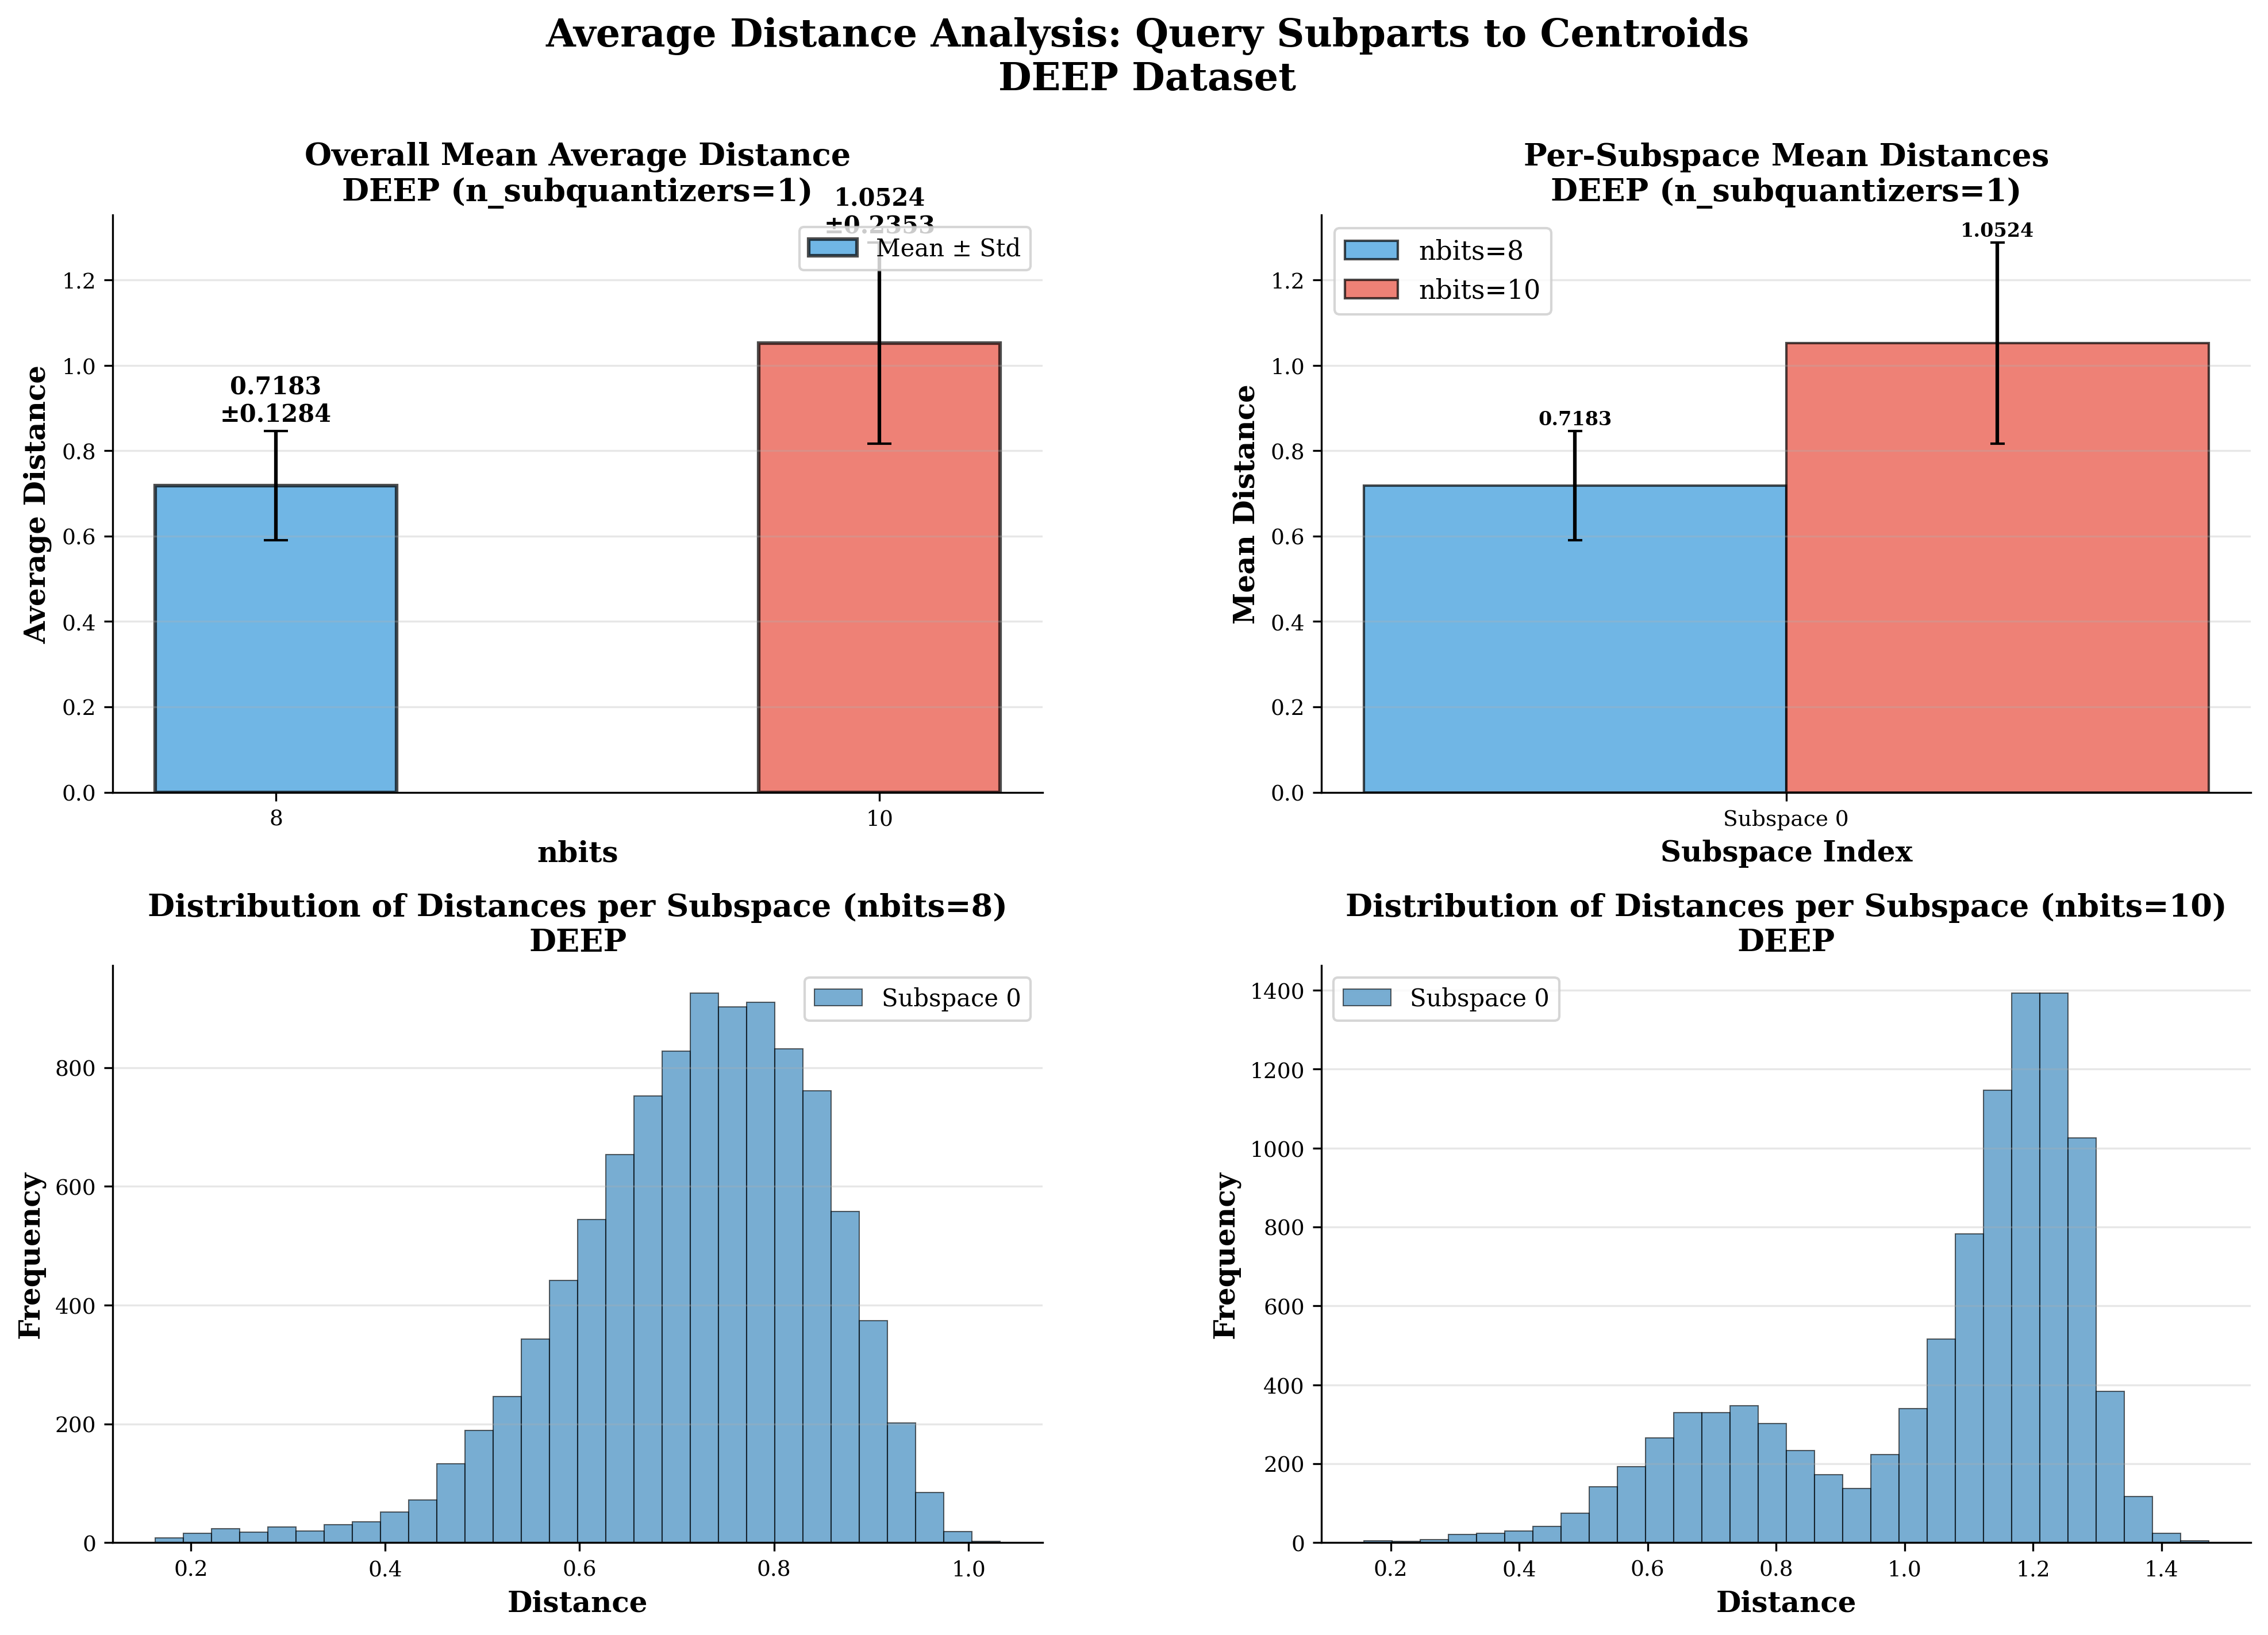


SUMMARY COMPARISON

nbits=8:
  Overall (averaged across subspaces):
    Mean: 0.718291
    Std:  0.128395
    Median: 0.732219

  Per-subspace statistics:
    Subspace 0: mean=0.718291, std=0.128395, median=0.732219, min=0.163326, max=1.032870

nbits=10:
  Overall (averaged across subspaces):
    Mean: 1.052352
    Std:  0.235330
    Median: 1.143822

  Per-subspace statistics:
    Subspace 0: mean=1.052352, std=0.235330, median=1.143822, min=0.157822, max=1.473699

Overall Improvement (nbits=8 → nbits=10): -46.51% reduction

Per-subspace improvement (nbits=8 → nbits=10):
  Subspace 0: -46.51% reduction (0.718291 → 1.052352)


In [18]:
# ============================================================================
# Average Distance of Query Subparts to Subquantizer Representatives
# ============================================================================
from scipy.spatial.distance import euclidean

# ============================================================================
# CONFIGURATION
# ============================================================================

# Use same configuration as t-SNE visualization cell above
# dataset_name = 'deep'  # Already defined above
# n_subquantizers_val = ...  # Already defined above
# nbits_list = [8, 10]  # Already defined above

# Number of queries to use for averaging (None = use all queries, or specify a number)
n_queries_for_avg = None  # Use all queries, or set to e.g., 100 to use first 100 queries

# ============================================================================
# Load experiment and data
# ============================================================================

config = dataset_config[dataset_name]
df = dataframes[dataset_name]

# Load queries
queries, _ = load_dataset(
    config['query_path'],
    None,
    config['dim'],
    db_chunk_size=None,
    qr_chunk_size=1000
)

# Limit number of queries if specified
if n_queries_for_avg is not None:
    queries = queries[:n_queries_for_avg]

print(f"Using {len(queries)} queries for averaging")
print(f"Dataset: {dataset_name.upper()}")
print(f"n_subquantizers: {n_subquantizers_val}")

# ============================================================================
# Compute average distances for each nbits value
# ============================================================================

results = {}  # Store results: {nbits: {'avg_distances': [...], 'mean_avg_distance': float}}

for nbits_val in nbits_list:
    print("\n" + "="*70)
    print(f"Processing nbits={nbits_val}")
    print("="*70)
    
    # Find the experiment in CSV
    experiment_row = df[
        (df['nbits'] == nbits_val) & 
        (df['n_subquantizers'] == n_subquantizers_val) &
        (df['train_size'] == config['train_size'])
    ].iloc[0] if len(df[
        (df['nbits'] == nbits_val) & 
        (df['n_subquantizers'] == n_subquantizers_val) &
        (df['train_size'] == config['train_size'])
    ]) > 0 else None
    
    if experiment_row is None:
        print(f"⚠️  Warning: No experiment found for {dataset_name} with nbits={nbits_val}, n_subquantizers={n_subquantizers_val}")
        print(f"   Skipping nbits={nbits_val}")
        continue
    
    experiment_folder = Path(experiment_row['experiment_folder'])
    model_path = experiment_folder / 'pq_model.index'
    
    if not model_path.exists():
        print(f"⚠️  Warning: Model not found: {model_path}")
        print(f"   Skipping nbits={nbits_val}")
        continue
    
    print(f"Loading experiment: {experiment_folder.name}")
    
    # Load PQ model
    pq_index = faiss.read_index(str(model_path))
    pq = pq_index.pq
    dim = pq.d
    n_subquantizers = pq.M
    
    if n_subquantizers != n_subquantizers_val:
        print(f"⚠️  Warning: Model has {n_subquantizers} subquantizers, expected {n_subquantizers_val}")
        print(f"   Skipping nbits={nbits_val}")
        continue
    
    # Get centroids
    ksub = 1 << nbits_val  # 2^nbits
    centroids = faiss.vector_to_array(pq.centroids).reshape(n_subquantizers, ksub, dim // n_subquantizers)
    subspace_dim = dim // n_subquantizers
    
    print(f"Centroids shape: {centroids.shape}")
    print(f"Subspace dimension: {subspace_dim}")
    
    # Compute distances for all queries - track per subspace
    # Initialize lists to store distances for each subspace
    subspace_distances_per_subspace = [[] for _ in range(n_subquantizers)]
    avg_distances_per_query = []  # Also keep overall average for comparison
    
    for query_idx, query in enumerate(queries):
        # Compute query codes
        query_2d = query.reshape(1, -1)
        query_codes = pq.compute_codes(query_2d)[0]
        
        # Split query into subspaces
        query_subspaces = []
        for m in range(n_subquantizers):
            start_idx = m * subspace_dim
            end_idx = (m + 1) * subspace_dim
            query_subspaces.append(query[start_idx:end_idx])
        
        # Compute distances for each subspace
        subspace_distances = []
        for m in range(n_subquantizers):
            centroid_idx = query_codes[m]
            query_subpart = query_subspaces[m]
            assigned_centroid = centroids[m][centroid_idx]
            distance = euclidean(query_subpart, assigned_centroid)
            subspace_distances.append(distance)
            # Store distance for this subspace
            subspace_distances_per_subspace[m].append(distance)
        
        # Average distance across all subspaces for this query
        avg_distance = np.mean(subspace_distances)
        avg_distances_per_query.append(avg_distance)
        
        if (query_idx + 1) % 100 == 0:
            print(f"  Processed {query_idx + 1}/{len(queries)} queries...")
    
    # Compute overall statistics (average across all subspaces)
    mean_avg_distance = np.mean(avg_distances_per_query)
    std_avg_distance = np.std(avg_distances_per_query)
    median_avg_distance = np.median(avg_distances_per_query)
    
    # Compute per-subspace statistics
    per_subspace_stats = {}
    for m in range(n_subquantizers):
        distances_m = subspace_distances_per_subspace[m]
        per_subspace_stats[m] = {
            'mean': np.mean(distances_m),
            'std': np.std(distances_m),
            'median': np.median(distances_m),
            'min': np.min(distances_m),
            'max': np.max(distances_m)
        }
    
    results[nbits_val] = {
        'avg_distances': avg_distances_per_query,
        'mean_avg_distance': mean_avg_distance,
        'std_avg_distance': std_avg_distance,
        'median_avg_distance': median_avg_distance,
        'per_subspace_distances': subspace_distances_per_subspace,
        'per_subspace_stats': per_subspace_stats
    }
    
    print(f"\nStatistics for nbits={nbits_val}:")
    print(f"  Overall (averaged across all subspaces):")
    print(f"    Mean: {mean_avg_distance:.6f}")
    print(f"    Std:  {std_avg_distance:.6f}")
    print(f"    Median: {median_avg_distance:.6f}")
    print(f"\n  Per-subspace statistics:")
    for m in range(n_subquantizers):
        stats = per_subspace_stats[m]
        print(f"    Subspace {m}: mean={stats['mean']:.6f}, std={stats['std']:.6f}, median={stats['median']:.6f}")

# ============================================================================
# Visualize results
# ============================================================================

if len(results) > 0:
    nbits_vals = sorted(results.keys())
    n_subspaces = n_subquantizers_val
    
    # Create figure with multiple subplots
    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)
    
    # Plot 1: Overall average distances (bar chart)
    ax1 = fig.add_subplot(gs[0, 0])
    mean_distances = [results[nbits]['mean_avg_distance'] for nbits in nbits_vals]
    std_distances = [results[nbits]['std_avg_distance'] for nbits in nbits_vals]
    
    bars = ax1.bar(nbits_vals, mean_distances, yerr=std_distances, 
                    capsize=5, alpha=0.7, color=['#3498db', '#e74c3c'], 
                    edgecolor='black', linewidth=1.5)
    
    # Add value labels on bars
    for i, (nbits, mean_dist, std_dist) in enumerate(zip(nbits_vals, mean_distances, std_distances)):
        ax1.text(nbits, mean_dist + std_dist + 0.01, 
                f'{mean_dist:.4f}\n±{std_dist:.4f}', 
                ha='center', va='bottom', fontweight='bold', fontsize=10)
    
    ax1.set_xlabel('nbits', fontweight='bold', fontsize=12)
    ax1.set_ylabel('Average Distance', fontweight='bold', fontsize=12)
    ax1.set_title(f'Overall Mean Average Distance\n{dataset_name.upper()} (n_subquantizers={n_subquantizers_val})', 
                  fontweight='bold', fontsize=13)
    ax1.set_xticks(nbits_vals)
    ax1.grid(True, alpha=0.3, axis='y')
    ax1.legend(['Mean ± Std'], loc='upper right')
    
    # Plot 2: Per-subspace mean distances (grouped bar chart)
    ax2 = fig.add_subplot(gs[0, 1])
    x = np.arange(n_subspaces)  # Subspace indices
    width = 0.35  # Width of bars
    
    colors = ['#3498db', '#e74c3c']
    for i, nbits_val in enumerate(nbits_vals):
        per_subspace_stats = results[nbits_val]['per_subspace_stats']
        means = [per_subspace_stats[m]['mean'] for m in range(n_subspaces)]
        stds = [per_subspace_stats[m]['std'] for m in range(n_subspaces)]
        offset = (i - 0.5) * width
        bars = ax2.bar(x + offset, means, width, yerr=stds, 
                       label=f'nbits={nbits_val}', alpha=0.7, 
                       color=colors[i], edgecolor='black', linewidth=1, capsize=3)
        
        # Add value labels
        for j, (mean_val, std_val) in enumerate(zip(means, stds)):
            ax2.text(x[j] + offset, mean_val + std_val + 0.005, 
                    f'{mean_val:.4f}', ha='center', va='bottom', 
                    fontsize=8, fontweight='bold')
    
    ax2.set_xlabel('Subspace Index', fontweight='bold', fontsize=12)
    ax2.set_ylabel('Mean Distance', fontweight='bold', fontsize=12)
    ax2.set_title(f'Per-Subspace Mean Distances\n{dataset_name.upper()} (n_subquantizers={n_subquantizers_val})', 
                  fontweight='bold', fontsize=13)
    ax2.set_xticks(x)
    ax2.set_xticklabels([f'Subspace {m}' for m in range(n_subspaces)])
    ax2.legend(fontsize=11)
    ax2.grid(True, alpha=0.3, axis='y')
    
    # Plot 3: Distribution of distances per subspace for nbits=8
    ax3 = fig.add_subplot(gs[1, 0])
    if 8 in results:
        per_subspace_distances = results[8]['per_subspace_distances']
        colors_subspace = plt.cm.tab10(np.linspace(0, 1, n_subspaces))
        for m in range(n_subspaces):
            ax3.hist(per_subspace_distances[m], bins=30, alpha=0.6, 
                    label=f'Subspace {m}', color=colors_subspace[m], 
                    edgecolor='black', linewidth=0.5)
        ax3.set_xlabel('Distance', fontweight='bold', fontsize=12)
        ax3.set_ylabel('Frequency', fontweight='bold', fontsize=12)
        ax3.set_title(f'Distribution of Distances per Subspace (nbits=8)\n{dataset_name.upper()}', 
                      fontweight='bold', fontsize=13)
        ax3.legend(fontsize=10)
        ax3.grid(True, alpha=0.3, axis='y')
    
    # Plot 4: Distribution of distances per subspace for nbits=10
    ax4 = fig.add_subplot(gs[1, 1])
    if 10 in results:
        per_subspace_distances = results[10]['per_subspace_distances']
        colors_subspace = plt.cm.tab10(np.linspace(0, 1, n_subspaces))
        for m in range(n_subspaces):
            ax4.hist(per_subspace_distances[m], bins=30, alpha=0.6, 
                    label=f'Subspace {m}', color=colors_subspace[m], 
                    edgecolor='black', linewidth=0.5)
        ax4.set_xlabel('Distance', fontweight='bold', fontsize=12)
        ax4.set_ylabel('Frequency', fontweight='bold', fontsize=12)
        ax4.set_title(f'Distribution of Distances per Subspace (nbits=10)\n{dataset_name.upper()}', 
                      fontweight='bold', fontsize=13)
        ax4.legend(fontsize=10)
        ax4.grid(True, alpha=0.3, axis='y')
    
    plt.suptitle(f'Average Distance Analysis: Query Subparts to Centroids\n{dataset_name.upper()} Dataset', 
                 fontsize=16, fontweight='bold', y=0.995)
    
    # Save figure
    output_dir = Path('/home/cpanourg/projects/2-hdvc/notebooks/general_results/figures')
    output_dir.mkdir(parents=True, exist_ok=True)
    filename = f"avg_distance_subparts_per_subspace_{dataset_name}_nsubq{n_subquantizers_val}.pdf"
    filepath = output_dir / filename
    fig.savefig(filepath, format='pdf', bbox_inches='tight', dpi=300)
    print(f"\n✅ Figure saved to: {filepath}")
    
    plt.show()
    
    # Print summary comparison
    print("\n" + "="*70)
    print("SUMMARY COMPARISON")
    print("="*70)
    for nbits_val in sorted(results.keys()):
        r = results[nbits_val]
        print(f"\nnbits={nbits_val}:")
        print(f"  Overall (averaged across subspaces):")
        print(f"    Mean: {r['mean_avg_distance']:.6f}")
        print(f"    Std:  {r['std_avg_distance']:.6f}")
        print(f"    Median: {r['median_avg_distance']:.6f}")
        print(f"\n  Per-subspace statistics:")
        per_subspace_stats = r['per_subspace_stats']
        for m in range(n_subspaces):
            stats = per_subspace_stats[m]
            print(f"    Subspace {m}: mean={stats['mean']:.6f}, std={stats['std']:.6f}, "
                  f"median={stats['median']:.6f}, min={stats['min']:.6f}, max={stats['max']:.6f}")
    
    if len(results) == 2:
        nbits_8_mean = results[8]['mean_avg_distance']
        nbits_10_mean = results[10]['mean_avg_distance']
        improvement = ((nbits_8_mean - nbits_10_mean) / nbits_8_mean) * 100
        print(f"\nOverall Improvement (nbits=8 → nbits=10): {improvement:.2f}% reduction")
        
        # Per-subspace improvement
        print(f"\nPer-subspace improvement (nbits=8 → nbits=10):")
        for m in range(n_subspaces):
            mean_8 = results[8]['per_subspace_stats'][m]['mean']
            mean_10 = results[10]['per_subspace_stats'][m]['mean']
            improvement_m = ((mean_8 - mean_10) / mean_8) * 100
            print(f"  Subspace {m}: {improvement_m:.2f}% reduction "
                  f"({mean_8:.6f} → {mean_10:.6f})")
else:
    print("\n⚠️  No results to visualize. Check that experiments exist for the specified configuration.")



In [ ]:
# ============================================================================
# Average Distance of Queries to K-Means Centroids
# ============================================================================
from scipy.spatial.distance import euclidean

# ============================================================================
# CONFIGURATION
# ============================================================================

# Use same configuration as above
# dataset_name = 'deep'  # Already defined above

# K-means configurations: number of centroids
k_centroids_list = [256, 1024]

# Number of queries to use (None = use all queries, or specify a number)
n_queries_for_kmeans = None  # Use all queries, or set to e.g., 100 to use first 100 queries

# Number of training samples for K-means (use training data from dataset)
n_train_samples = 1000000  # Use 100K samples for training K-means

# K-means training parameters
kmeans_niter = 20  # Number of iterations
kmeans_verbose = True
kmeans_seed = 42


In [ ]:
# ============================================================================
# Load data
# ============================================================================

config = dataset_config[dataset_name]
df = dataframes[dataset_name]

# Load queries
queries, _ = load_dataset(
    config['query_path'],
    None,
    config['dim'],
    db_chunk_size=None,
    qr_chunk_size=1000
)

if n_queries_for_kmeans is not None:
    queries = queries[:n_queries_for_kmeans]

print(f"Using {len(queries)} queries for evaluation")
print(f"Dataset: {dataset_name.upper()}")
print(f"Vector dimension: {queries.shape[1]}")

# Load training data for K-means
print(f"\nLoading {n_train_samples} training samples for K-means...")
train_data, _ = load_dataset(
    config['dataset_path'],
    None,
    config['dim'],
    db_chunk_size=n_train_samples,
    qr_chunk_size=None
)
train_data = train_data[:n_train_samples]
print(f"Training data shape: {train_data.shape}")
# Limit number of queries

Using 10000 queries for evaluation
Dataset: DEEP
Vector dimension: 96

Loading 1000000 training samples for K-means...
Training data shape: (1000000, 96)


In [29]:


# ============================================================================
# Train K-means and compute distances for each k value
# ============================================================================

results = {}  # Store results: {k: {'distances': [...], 'mean_distance': float, ...}}

for k_centroids in k_centroids_list:
    print("\n" + "="*70)
    print(f"Processing K-means with k={k_centroids} centroids")
    print("="*70)
    
    # Train K-means using faiss
    dim = train_data.shape[1]
    kmeans = faiss.Kmeans(dim, k_centroids, niter=kmeans_niter, verbose=kmeans_verbose, seed=kmeans_seed)
    kmeans.train(train_data.astype('float32'))
    
    centroids = kmeans.centroids  # Shape: (k_centroids, dim)
    print(f"Centroids shape: {centroids.shape}")
    
    # Compute distances for all queries using faiss (optimized)
    queries_float32 = queries.astype('float32')
    
    # Create a faiss index with the centroids for efficient search
    index = faiss.IndexFlatL2(dim)
    index.add(centroids)
    
    # Search for nearest centroid for each query
    distances_squared, indices = index.search(queries_float32, 1)  # k=1: find nearest
    
    # Convert squared distances to regular distances
    query_distances = np.sqrt(distances_squared.flatten()).tolist()
    
    print(f"  Computed distances for all {len(queries)} queries")
    
    # Compute statistics
    mean_distance = np.mean(query_distances)
    std_distance = np.std(query_distances)
    median_distance = np.median(query_distances)
    min_distance = np.min(query_distances)
    max_distance = np.max(query_distances)
    
    results[k_centroids] = {
        'distances': query_distances,
        'mean_distance': mean_distance,
        'std_distance': std_distance,
        'median_distance': median_distance,
        'min_distance': min_distance,
        'max_distance': max_distance,
        'centroids': centroids
    }
    
    print(f"\nStatistics for k={k_centroids}:")
    print(f"  Mean distance: {mean_distance:.6f}")
    print(f"  Std distance: {std_distance:.6f}")
    print(f"  Median distance: {median_distance:.6f}")
    print(f"  Min distance: {min_distance:.6f}")
    print(f"  Max distance: {max_distance:.6f}")



Processing K-means with k=256 centroids
Sampling a subset of 65536 / 1000000 for training
Clustering 65536 points in 96D to 256 clusters, redo 1 times, 20 iterations
  Preprocessing in 0.11 s
  Iteration 19 (0.19 s, search 0.16 s): objective=34391.3 imbalance=1.093 nsplit=0       
Centroids shape: (256, 96)
  Computed distances for all 10000 queries

Statistics for k=256:
  Mean distance: 0.717841
  Std distance: 0.129832
  Median distance: 0.730654
  Min distance: 0.156938
  Max distance: 1.015473

Processing K-means with k=1024 centroids
Sampling a subset of 262144 / 1000000 for training
Clustering 262144 points in 96D to 1024 clusters, redo 1 times, 20 iterations
  Preprocessing in 0.16 s
  Iteration 19 (1.75 s, search 1.64 s): objective=121187 imbalance=1.115 nsplit=0       
Centroids shape: (1024, 96)
  Computed distances for all 10000 queries

Statistics for k=1024:
  Mean distance: 0.672860
  Std distance: 0.131985
  Median distance: 0.685496
  Min distance: 0.138790
  Max dist


Processing K-means with k=256 centroids
Sampling a subset of 65536 / 1000000 for training
Clustering 65536 points in 96D to 256 clusters, redo 1 times, 20 iterations
  Preprocessing in 0.11 s
  Iteration 19 (0.34 s, search 0.30 s): objective=34391.3 imbalance=1.093 nsplit=0       
Centroids shape: (256, 96)
  Computed distances for all 10000 queries

Statistics for k=256:
  Mean distance: 0.717841
  Std distance: 0.129832
  Median distance: 0.730654
  Min distance: 0.156938
  Max distance: 1.015473

Processing K-means with k=1024 centroids
Sampling a subset of 262144 / 1000000 for training
Clustering 262144 points in 96D to 1024 clusters, redo 1 times, 20 iterations
  Preprocessing in 0.15 s
  Iteration 19 (2.04 s, search 1.92 s): objective=121187 imbalance=1.115 nsplit=0       
Centroids shape: (1024, 96)
  Computed distances for all 10000 queries

Statistics for k=1024:
  Mean distance: 0.672860
  Std distance: 0.131985
  Median distance: 0.685496
  Min distance: 0.138790
  Max dist

/tmp/ipykernel_2760620/2243048494.py:111: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax3.boxplot(box_data, labels=[f'k={k}' for k in k_vals],



✅ Figure saved to: /home/cpanourg/projects/2-hdvc/notebooks/general_results/figures/kmeans_distance_comparison_deep_k256_k1024.pdf


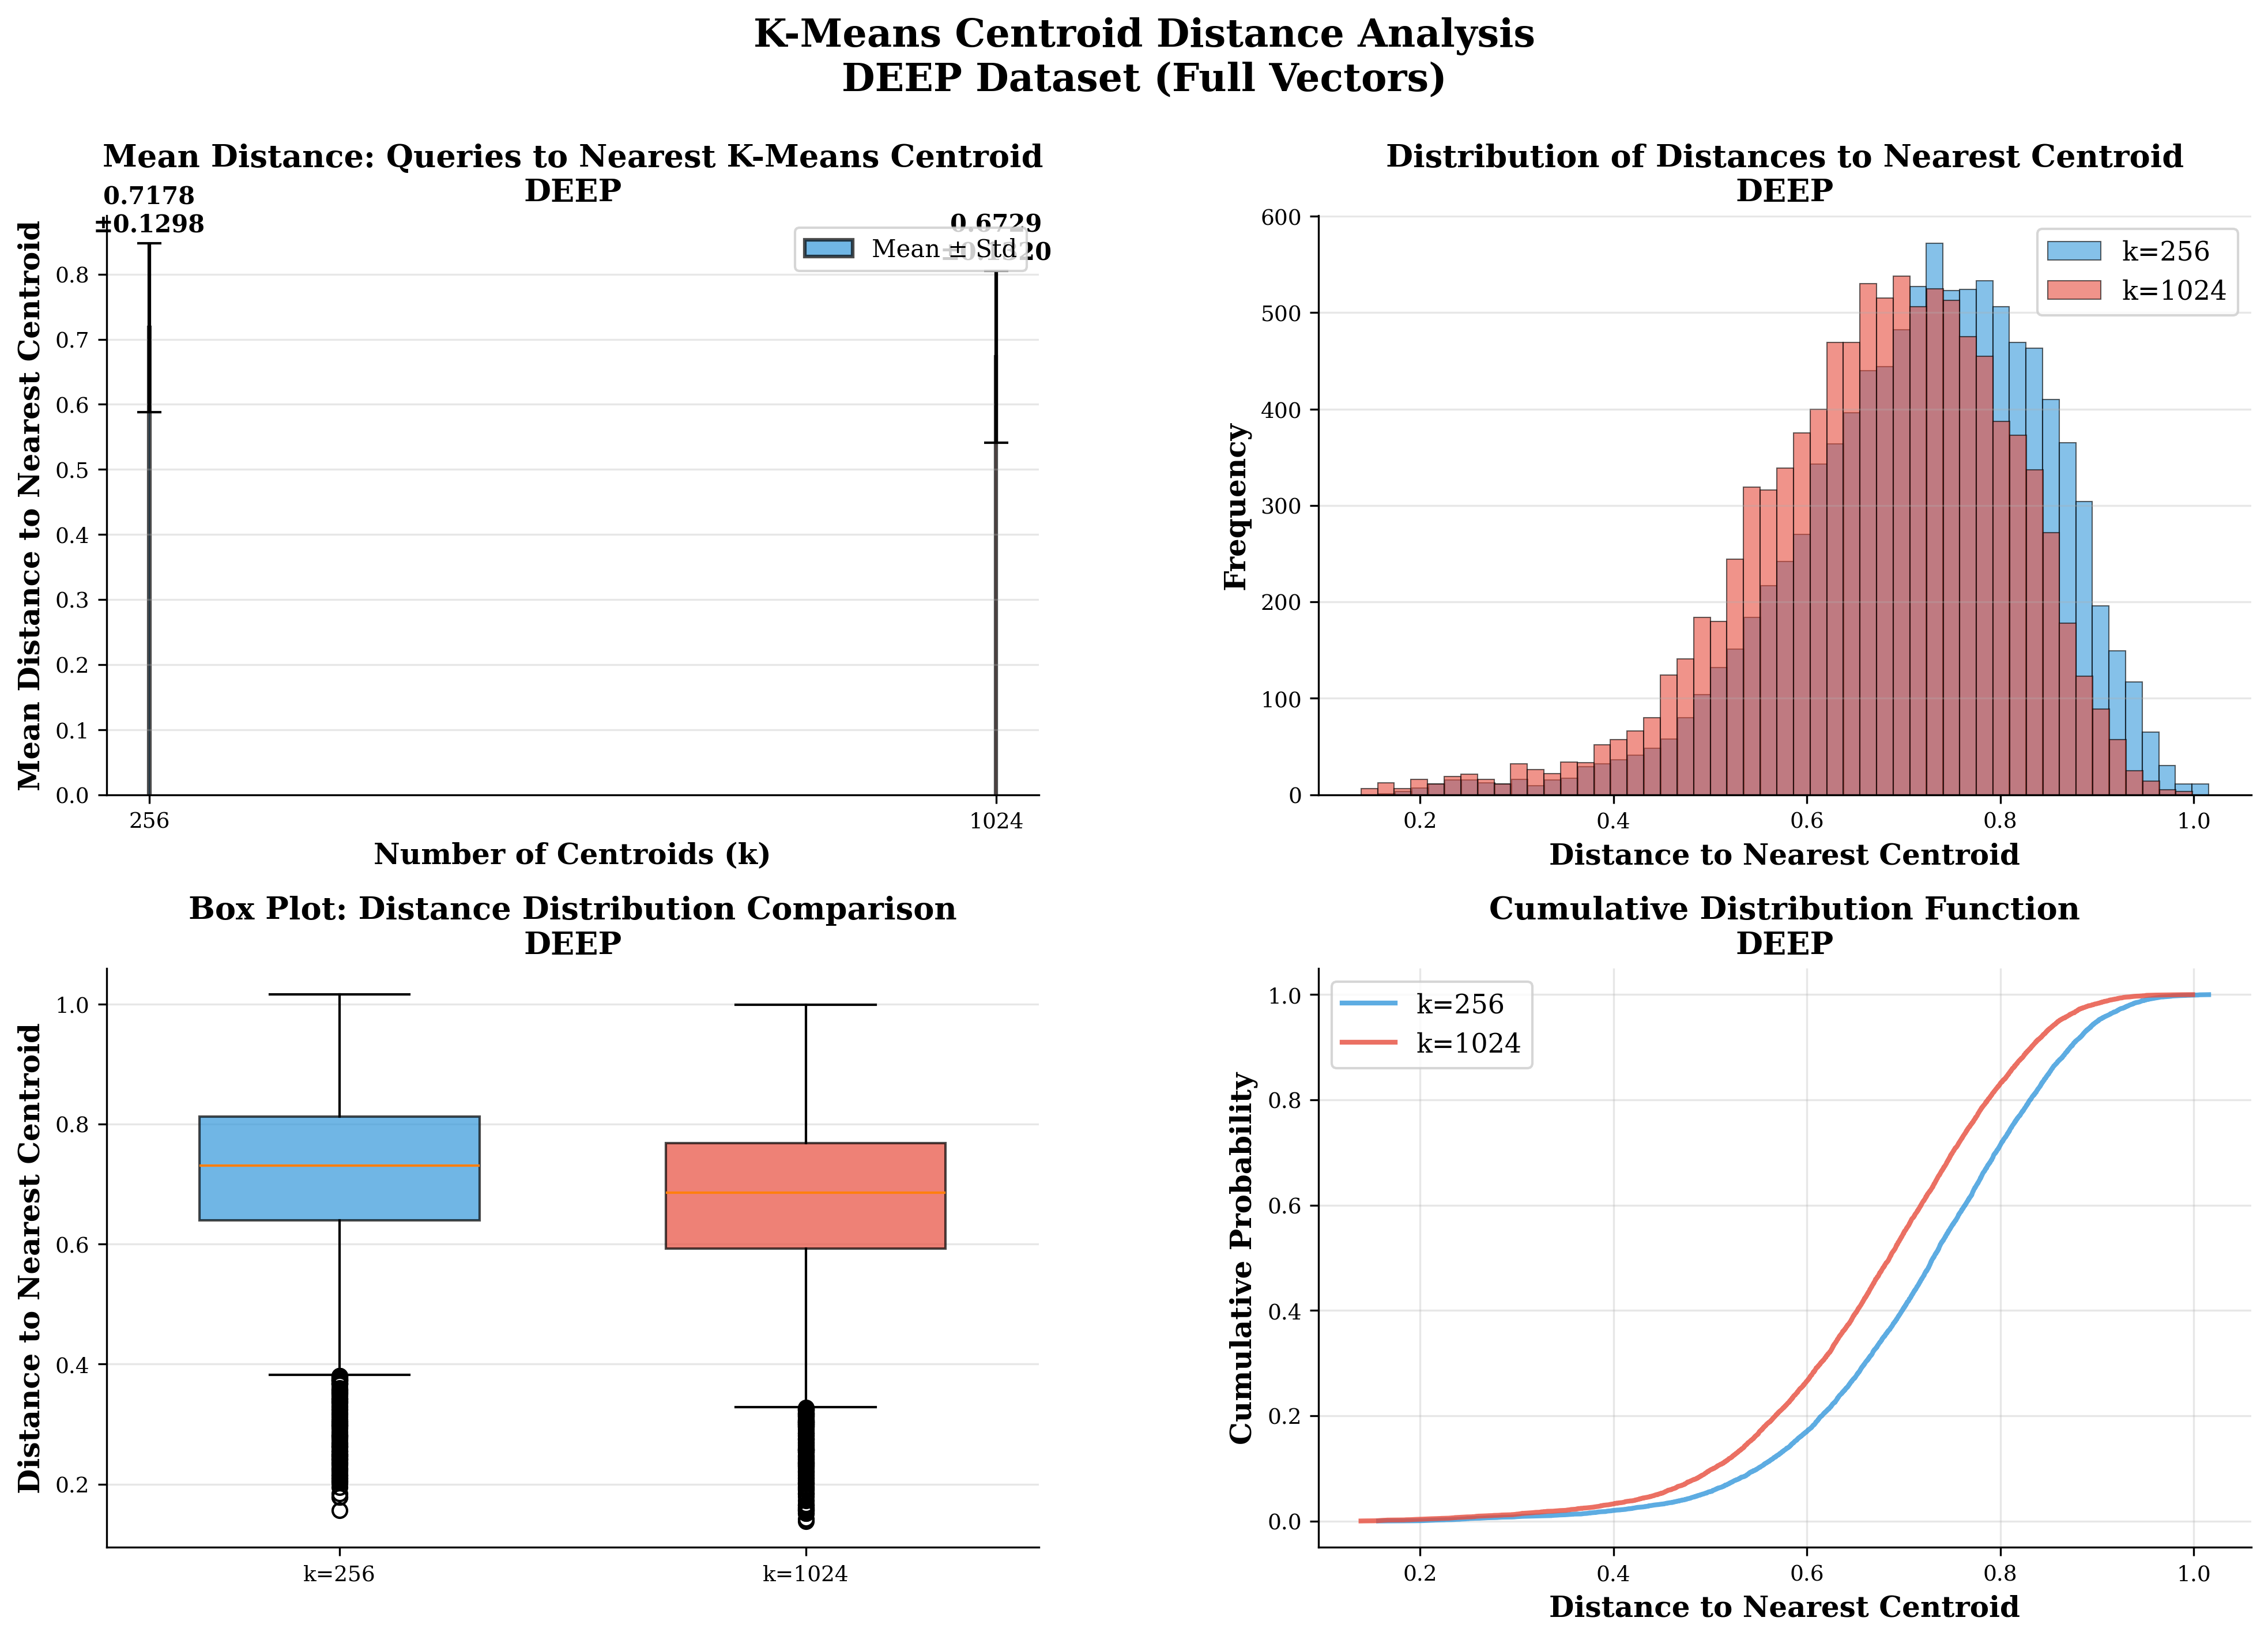


SUMMARY COMPARISON

k=256 centroids:
  Mean distance: 0.717841
  Std distance: 0.129832
  Median distance: 0.730654
  Min distance: 0.156938
  Max distance: 1.015473

k=1024 centroids:
  Mean distance: 0.672860
  Std distance: 0.131985
  Median distance: 0.685496
  Min distance: 0.138790
  Max distance: 0.998904

Improvement (k=256 → k=1024): 6.27% reduction
  k=256: 0.717841
  k=1024: 0.672860
  Difference: 0.044981


In [ ]:

# ============================================================================
# Visualize results
# ============================================================================

if len(results) > 0:
    k_vals = sorted(results.keys())
    
    # Create figure with multiple subplots
    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)
    
    # Plot 1: Mean distances comparison (bar chart)
    ax1 = fig.add_subplot(gs[0, 0])
    mean_distances = [results[k]['mean_distance'] for k in k_vals]
    std_distances = [results[k]['std_distance'] for k in k_vals]
    
    colors = ['#3498db', '#e74c3c']
    bars = ax1.bar(k_vals, mean_distances, yerr=std_distances, 
                    capsize=5, alpha=0.7, color=colors[:len(k_vals)], 
                    edgecolor='black', linewidth=1.5)
    
    # Add value labels on bars
    for i, (k, mean_dist, std_dist) in enumerate(zip(k_vals, mean_distances, std_distances)):
        ax1.text(k, mean_dist + std_dist + 0.01, 
                f'{mean_dist:.4f}\n±{std_dist:.4f}', 
                ha='center', va='bottom', fontweight='bold', fontsize=10)
    
    ax1.set_xlabel('Number of Centroids (k)', fontweight='bold', fontsize=12)
    ax1.set_ylabel('Mean Distance to Nearest Centroid', fontweight='bold', fontsize=12)
    ax1.set_title(f'Mean Distance: Queries to Nearest K-Means Centroid\n{dataset_name.upper()}', 
                  fontweight='bold', fontsize=13)
    ax1.set_xticks(k_vals)
    ax1.grid(True, alpha=0.3, axis='y')
    ax1.legend(['Mean ± Std'], loc='upper right')
    
    # Plot 2: Distribution comparison
    ax2 = fig.add_subplot(gs[0, 1])
    for i, k_val in enumerate(k_vals):
        distances = results[k_val]['distances']
        ax2.hist(distances, bins=50, alpha=0.6, label=f'k={k_val}', 
                color=colors[i], edgecolor='black', linewidth=0.5)
    
    ax2.set_xlabel('Distance to Nearest Centroid', fontweight='bold', fontsize=12)
    ax2.set_ylabel('Frequency', fontweight='bold', fontsize=12)
    ax2.set_title(f'Distribution of Distances to Nearest Centroid\n{dataset_name.upper()}', 
                  fontweight='bold', fontsize=13)
    ax2.legend(fontsize=11)
    ax2.grid(True, alpha=0.3, axis='y')
    
    # Plot 3: Box plot comparison
    ax3 = fig.add_subplot(gs[1, 0])
    box_data = [results[k]['distances'] for k in k_vals]
    bp = ax3.boxplot(box_data, labels=[f'k={k}' for k in k_vals], 
                     patch_artist=True, widths=0.6)
    
    for patch, color in zip(bp['boxes'], colors[:len(k_vals)]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax3.set_ylabel('Distance to Nearest Centroid', fontweight='bold', fontsize=12)
    ax3.set_title(f'Box Plot: Distance Distribution Comparison\n{dataset_name.upper()}', 
                  fontweight='bold', fontsize=13)
    ax3.grid(True, alpha=0.3, axis='y')
    
    # Plot 4: Cumulative distribution
    ax4 = fig.add_subplot(gs[1, 1])
    for i, k_val in enumerate(k_vals):
        distances = np.sort(results[k_val]['distances'])
        cumulative = np.arange(1, len(distances) + 1) / len(distances)
        ax4.plot(distances, cumulative, label=f'k={k_val}', 
                color=colors[i], linewidth=2, alpha=0.8)
    
    ax4.set_xlabel('Distance to Nearest Centroid', fontweight='bold', fontsize=12)
    ax4.set_ylabel('Cumulative Probability', fontweight='bold', fontsize=12)
    ax4.set_title(f'Cumulative Distribution Function\n{dataset_name.upper()}', 
                  fontweight='bold', fontsize=13)
    ax4.legend(fontsize=11)
    ax4.grid(True, alpha=0.3)
    
    plt.suptitle(f'K-Means Centroid Distance Analysis\n{dataset_name.upper()} Dataset (Full Vectors)', 
                 fontsize=16, fontweight='bold', y=0.995)
    
    # Save figure
    output_dir = Path('/home/cpanourg/projects/2-hdvc/notebooks/general_results/figures')
    output_dir.mkdir(parents=True, exist_ok=True)
    filename = f"kmeans_distance_comparison_{dataset_name}_k256_k1024.pdf"
    filepath = output_dir / filename
    fig.savefig(filepath, format='pdf', bbox_inches='tight', dpi=300)
    print(f"\n✅ Figure saved to: {filepath}")
    
    plt.show()
    
    # Print summary comparison
    print("\n" + "="*70)
    print("SUMMARY COMPARISON")
    print("="*70)
    for k_val in sorted(results.keys()):
        r = results[k_val]
        print(f"\nk={k_val} centroids:")
        print(f"  Mean distance: {r['mean_distance']:.6f}")
        print(f"  Std distance: {r['std_distance']:.6f}")
        print(f"  Median distance: {r['median_distance']:.6f}")
        print(f"  Min distance: {r['min_distance']:.6f}")
        print(f"  Max distance: {r['max_distance']:.6f}")
    
    if len(results) == 2:
        k256_mean = results[256]['mean_distance']
        k1024_mean = results[1024]['mean_distance']
        improvement = ((k256_mean - k1024_mean) / k256_mean) * 100
        print(f"\nImprovement (k=256 → k=1024): {improvement:.2f}% reduction")
        print(f"  k=256: {k256_mean:.6f}")
        print(f"  k=1024: {k1024_mean:.6f}")
        print(f"  Difference: {k256_mean - k1024_mean:.6f}")
else:
    print("\n⚠️  No results to visualize.")



In [30]:
import faiss 

faiss.ProductQuantizer()

<faiss.swigfaiss_avx512.ProductQuantizer; proxy of <Swig Object of type 'faiss::ProductQuantizer *' at 0x7f8964b83f90> >

In [34]:
import faiss
import numpy as np

# xb: (nb, d) float32 database vectors
# xq: (nq, d) float32 query vectors
# both must be np.float32 and C-contiguous

xb = train_data.astype(np.float32)
xq = queries.astype(np.float32)

d = xb.shape[1]

m = 16        # number of subquantizers (d must be divisible by m)
nbits = 8     # bits per subquantizer (usually 8 => 256 centroids per subspace)

index = faiss.IndexPQ(d, m, nbits)   # <- NO IVF / NO HNSW

# IMPORTANT: PQ needs training (k-means in each subspace)
index.train(xb)

# Add vectors (they are stored as PQ codes)
index.add(xb)

k = 10
# ADC distances are returned as squared L2; I contains ids
D_adc_sq, I_adc = index.search(xq, k)

# Compute exact Euclidean distances for the same pairs
D_exact = np.zeros_like(D_adc_sq, dtype=np.float32)
for qi in range(len(xq)):
    # gather the true vectors for the returned ids
    xb_sel = xb[I_adc[qi]]  # shape (k, d)
    diff = xb_sel - xq[qi]
    D_exact[qi] = np.sum(diff * diff, axis=1)  # squared L2

# Convert to Euclidean distances
D_adc = np.sqrt(D_adc_sq)
D_true = np.sqrt(D_exact)

# Relative error per returned distance
rel_error = np.abs(D_adc - D_true) / (D_true + 1e-12)

# Report summary
print("ADC vs Exact (Euclidean) distances for returned top-k ids")
print(f"k = {k}, queries = {len(xq)}, dim = {d}")
print(f"Mean relative error: {rel_error.mean():.6f}")
print(f"Median relative error: {np.median(rel_error):.6f}")
print(f"Max relative error: {rel_error.max():.6f}")

# Show first query as a sanity check
print("\nQuery 0 sample:")
print("IDs (ADC):", I_adc[0])
print("ADC distances:", D_adc[0])
print("Exact distances:", D_true[0])
print("Relative error:", rel_error[0])


ADC vs Exact (Euclidean) distances for returned top-k ids
k = 10, queries = 10000, dim = 96
Mean relative error: 48352932.000000
Median relative error: 0.052928
Max relative error: 427082842112.000000

Query 0 sample:
IDs (ADC): [109488 936063 759199 300406 545689 223620 538280 216572 749060 815621]
ADC distances: [0.8122  0.81588 0.82594 0.82874 0.85567 0.85661 0.87721 0.88007 0.88414
 0.88753]
Exact distances: [0.81423 0.88032 0.86978 0.79306 0.81057 0.84877 0.92113 1.00561 0.9339
 0.93775]
Relative error: [0.00249 0.0732  0.0504  0.04499 0.05564 0.00923 0.04768 0.12484 0.05328
 0.05355]


In [35]:
# ============================================================================
# Average relative error (ADC vs exact) across queries x database
# Computes mean/median/max relative error on distances for a sample of queries
# and up to db_eval_size database vectors. Uses chunking to control memory.
# ============================================================================

from scipy.spatial.distance import cdist

# Configuration
nq_eval = 1000          # number of queries to evaluate
db_eval_size = 1_000_000  # maximum number of database vectors to evaluate
chunk_size = 20000        # process database in chunks to limit memory

dataset_name = dataset_name  # reuse from above
config = dataset_config[dataset_name]

# Load queries (limit to nq_eval)
queries_eval, _ = load_dataset(
    config['query_path'],
    None,
    config['dim'],
    db_chunk_size=None,
    qr_chunk_size=nq_eval
)
queries_eval = queries_eval[:nq_eval].astype(np.float32)

# Load database (limit to db_eval_size)
db_full, _ = load_dataset(
    config['dataset_path'],
    None,
    config['dim'],
    db_chunk_size=db_eval_size,
    qr_chunk_size=None
)
db_full = db_full[:db_eval_size].astype(np.float32)
nb = len(db_full)
print(f"Evaluating {len(queries_eval)} queries against {nb} database vectors (dim={config['dim']})")

# Train PQ (if not already)
pq = faiss.ProductQuantizer(config['dim'], m, nbits)
pq.train(db_full)

# Compute codes for database
codes = pq.compute_codes(db_full)

# Prepare distance tables for queries
ksub = 1 << pq.nbits
centroids = faiss.vector_to_array(pq.centroids).reshape(m, ksub, config['dim'] // m)
dis_tables = compute_distance_tables_vectorized(queries_eval, centroids, m, ksub, config['dim'])

# Accumulators
sum_rel = 0.0
count = 0
max_rel = 0.0
min_rel = np.inf

n_chunks = (nb + chunk_size - 1) // chunk_size
for ci in range(n_chunks):
    start = ci * chunk_size
    end = min(nb, (ci + 1) * chunk_size)
    db_chunk = db_full[start:end]
    codes_chunk = codes[start:end]
    if len(db_chunk) == 0:
        continue
    
    # Exact squared distances
    exact_sq = cdist(queries_eval, db_chunk, metric='sqeuclidean').astype(np.float32)
    
    # ADC squared distances
    adc_sq = adc_distances_batch_numba(dis_tables, codes_chunk, m)
    
    # Relative error (on Euclidean distance)
    adc = np.sqrt(adc_sq)
    exact = np.sqrt(exact_sq)
    rel = np.abs(adc - exact) / (exact + 1e-12)
    
    sum_rel += rel.sum()
    count += rel.size
    max_rel = max(max_rel, rel.max())
    min_rel = min(min_rel, rel.min())
    
    if (ci + 1) % 10 == 0 or end == nb:
        print(f"  Processed chunk {ci+1}/{n_chunks} (db indices {start}-{end})")

mean_rel = sum_rel / count
print("\nRelative error summary (ADC vs exact, Euclidean):")
print(f"  Mean:   {mean_rel:.6f}")
print(f"  Min:    {min_rel:.6f}")
print(f"  Max:    {max_rel:.6f}")
print(f"  Count:  {count}")


Evaluating 1000 queries against 1000000 database vectors (dim=96)
  Processed chunk 10/50 (db indices 180000-200000)
  Processed chunk 20/50 (db indices 380000-400000)
  Processed chunk 30/50 (db indices 580000-600000)
  Processed chunk 40/50 (db indices 780000-800000)
  Processed chunk 50/50 (db indices 980000-1000000)

Relative error summary (ADC vs exact, Euclidean):
  Mean:   4977.869227
  Min:    0.000000
  Max:    390913490944.000000
  Count:  1000000000
